<a href="https://colab.research.google.com/github/yossefPartouche/Intro_NLP/blob/main/NER_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing
![](https://i.imgur.com/qkg2E2D.png)

## Assignment 002 - NER Tagger

> Notebook by:
> - NLP Course Staff
## Revision History

| Version | Date       | User        | Content / Changes                                                   |
|---------|------------|-------------|---------------------------------------------------------------------|
| 0.1.000 | 2026        | course staff | Updated submission protocol (direct from Colab) |

## Overview
In this assignment, you will build a complete training and testing pipeline for a neural sequential tagger for named entities using LSTM.

## Dataset
You will work with the ReCoNLL 2003 dataset, a corrected version of the [CoNLL 2003 dataset](https://www.clips.uantwerpen.be/conll2003/ner/):

**Click on the links below to download the data files.**
- [Train data](https://drive.google.com/file/d/1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf/view?usp=sharing)

- [Dev data](https://drive.google.com/file/d/1rdUida-j3OXcwftITBlgOh8nURhAYUDw/view?usp=sharing)

- [Test data](https://drive.google.com/file/d/137Ht40OfflcsE6BIYshHbT5b2iIJVaDx/view?usp=sharing)

As you will see, the annotated texts are labeled according to the `IOB` annotation scheme (more on this below), for 3 entity types: Person, Organization, Location.

## Your Implementation

This notebook **is** the assignment template. To work on it, open it in Colab using the badge below and then **File → Save a copy in Drive** to create your own editable copy.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1KGkObwUn5QQm_v0nB0nAUlB4YrwThuzl#scrollTo=Z-fCqGh9ybgm)

Work through the cells in order — each section's instructions are written above the corresponding code cell.

Good Luck 🤗


<!-- ## NER schemes:  

> `IO`: is the simplest scheme that can be applied to this task. In this scheme, each token from the dataset is assigned one of two tags: an inside tag (`I`) and an outside tag (`O`). The `I` tag is for named entities, whereas the `O` tag is for normal words. This scheme has a limitation, as it cannot correctly encode consecutive entities of the same type.

> `IOB`: This scheme is also referred to in the literature as BIO and has been adopted by the Conference on Computational Natural Language Learning (CoNLL) [1]. It assigns a tag to each word in the text, determining whether it is the beginning (`B`) of a known named entity, inside (`I`) it, or outside (`O`) of any known named entities.

> `IOE`: This scheme works nearly identically to `IOB`, but it indicates the end of the entity (`E` tag) instead of its beginning.

> `IOBES`: An alternative to the IOB scheme is `IOBES`, which increases the amount of information related to the boundaries of named entities. In addition to tagging words at the beginning (`B`), inside (`I`), end (`E`), and outside (`O`) of a named entity. It also labels single-token entities with the tag `S`.

> `BI`: This scheme tags entities in a similar method to `IOB`. Additionally, it labels the beginning of non-entity words with the tag B-O and the rest as I-O.

> `IE`: This scheme works exactly like `IOE` with the distinction that it labels the end of non-entity words with the tag `E-O` and the rest as `I-O`.

> `BIES`: This scheme encodes the entities similar to `IOBES`. In addition, it also encodes the non-entity words using the same method. It uses `B-O` to tag the beginning of non-entity words, `I-O` to tag the inside of non-entity words, and `S-O` for single non-entity tokens that exist between two entities. -->


## NER Schemes

### IO
- **Description**: The simplest scheme for named entity recognition (NER).
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Limitation**: Cannot correctly encode consecutive entities of the same type.

### IOB (BIO)
- **Description**: Adopted by the Conference on Computational Natural Language Learning (CoNLL).
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Advantage**: Can encode the boundaries of consecutive entities.

### IOE
- **Description**: Similar to IOB, but indicates the end of an entity.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
- **Advantage**: Focuses on the end boundary of entities.

### IOBES
- **Description**: An extension of IOB with additional boundary information.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
- **Advantage**: Provides more detailed boundary information for named entities.

### BI
- **Description**: Tags entities similarly to IOB and labels the beginning of non-entity words.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Distinguishes the beginning of non-entity sequences.

### IE
- **Description**: Similar to IOE but for non-entity words.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `E-O`: End of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Highlights the end of non-entity sequences.

### BIES
- **Description**: Encodes both entities and non-entity words using the IOBES method.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
  - `S-O`: Single non-entity token.
- **Advantage**: Comprehensive encoding for both entities and non-entities.




# Set up

First, let's clean up the previous cloning and set up your personal GitHub Classroom repository. You'll need to provide your repository URL in the next code cell.

### Clean Up and Clone Your Repository

1.  **Replace `YOUR_GITHUB_CLASSROOM_REPO_URL`** in the next code cell with the actual URL of your assignment repository.
    *   Example: `https://github.com/NLP-Reichman/2026-assignment-2-your-username.git`
2.  **Replace `YOUR_REPO_NAME_HERE`** with the name of the directory that GitHub creates when you clone your repository (usually the last part of the URL without `.git`).
    *   Example: If your URL is `.../2026-assignment-2-your-username.git`, the `REPO_NAME` would be `2026-assignment-2-your-username`.
3.  **Run the cell** to clean up any previous cloned directories, clone your personal repository, and navigate into it.

In [61]:
# ── SETUP: Clone repo and ensure data/ directory has standard filenames ──────
#
# Two problems this cell solves:
#   1. NAMING MISMATCH  – Drive copies may be named connl03_train.txt etc.
#      The autograder expects the bare names train.txt / dev.txt / test.txt
#      inside a local "data/" folder.
#   2. SYMLINK BAN on Drive – os.symlink() raises OSError on Google Drive
#      (network FS, no symlink support).  We use shutil.copy2() instead.

import os, shutil, subprocess

# ── 1. Clone the classroom repo ───────────────────────────────────────────────
#    Replace REPO_URL / REPO_NAME with your own classroom assignment values.
REPO_URL  = "https://github.com/NLP-Reichman/assignment-2-ner-yossi_partouche.git"
REPO_NAME = "assignment-2-ner-yossi_partouche"

os.chdir("/content")

if not os.path.isdir(REPO_NAME):
    # subprocess avoids putting !git inside an if-block (invalid IPython syntax)
    subprocess.run(["git", "clone", REPO_URL], check=True)
else:
    print(f"Repo '{REPO_NAME}' already present — skipping clone.")

os.chdir(f"/content/{REPO_NAME}")
print("Working directory:", os.getcwd())

# ── 2. Build a canonical local data/ directory ────────────────────────────────
#   Priority for each split:
#     a) standard name already exists in data/       → nothing to do
#     b) prefixed name exists in data/               → copy to standard name
#     c) file exists somewhere on mounted Drive      → copy to standard name
#     d) not found anywhere                          → print a clear error

os.makedirs("data", exist_ok=True)

DRIVE_BASE = "/content/drive/MyDrive/Colab Notebooks/NLP/NERnet/data"
SPLITS = {
    "train.txt": [
        "data/connl03_train.txt",
        f"{DRIVE_BASE}/connl03_train.txt",
        f"{DRIVE_BASE}/train.txt",
    ],
    "dev.txt": [
        "data/connl03_dev.txt",
        f"{DRIVE_BASE}/connl03_dev.txt",
        f"{DRIVE_BASE}/dev.txt",
    ],
    "test.txt": [
        "data/connl03_test.txt",
        f"{DRIVE_BASE}/connl03_test.txt",
        f"{DRIVE_BASE}/test.txt",
    ],
}

for std_name, fallbacks in SPLITS.items():
    dst = os.path.join("data", std_name)
    if os.path.exists(dst):
        print(f"  ✓  data/{std_name}  (already present)")
        continue
    copied = False
    for src in fallbacks:
        if os.path.exists(src):
            shutil.copy2(src, dst)   # plain file copy — works on Drive + local FS
            print(f"  ✓ data/{std_name}  ← copied from {src}")
            copied = True
            break
    if not copied:
        print(f"  ✗  data/{std_name}  NOT FOUND — download from the assignment "
              f"page and place it in data/")

print("\ndata/ contents:", sorted(os.listdir("data")))


Repo 'assignment-2-ner-yossi_partouche' already present — skipping clone.
Working directory: /content/assignment-2-ner-yossi_partouche
  ✓  data/train.txt  ← copied from data/connl03_train.txt
  ✓  data/dev.txt  ← copied from data/connl03_dev.txt
  ✓  data/test.txt  ← copied from data/connl03_test.txt

data/ contents: ['connl03_dev.txt', 'connl03_test.txt', 'connl03_train.txt', 'dev.txt', 'glove', 'test.txt', 'train.txt']


In [ ]:
# Any additional needed libraries
# !pip install --q

In [66]:
# Standard Library Imports
import zipfile
import os
import sys
import copy
import random
import warnings
from collections import defaultdict
from typing import Optional
import shutil
import urllib.request

# ML
import numpy as np
import scipy as sp
import pandas as pd

# Visual
import matplotlib
import seaborn as sns
from tqdm import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt
from IPython.display import display

# DL
import torch as th
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

# Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score , roc_auc_score, classification_report, confusion_matrix, precision_recall_fscore_support

try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False

In [3]:
SEED = 42
# Set the random seed for Python
random.seed(SEED)

# Set the random seed for numpy
np.random.seed(SEED)

# Set the random seed for pytorch
th.manual_seed(SEED)

# If using CUDA (for GPU operations)
th.cuda.manual_seed(SEED)

# ── FIXED: Auto-detect GPU; fall back to CPU so the notebook runs everywhere ──
DEVICE = "cuda" if th.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

DataType = list[tuple[list[str], list[str]]]


# Part 1 - Dataset Preparation

## Step 1: Read Data
Write a function for reading the data from a single file (of the ones that are provided above).   
- The function recieves a filepath
- The funtion encodes every sentence individually using a pair of lists, one list contains the words and one list contains the tags.
- Each list pair will be added to a general list (data), which will be returned back from the function.

Example output:
```
[
  (['At','Trent','Bridge',':'],['O','B-LOC','I-LOC','O']),
  ([...],[...]),
  ...
]
```

In [4]:
def read_data(filepath:str) -> DataType:
  """
  Read data from a single file.
  The function recieves a filepath
  The funtion encodes every sentence using a pair of lists, one list contains the words and one list contains the tags.
  :param filepath: path to the file
  :return: data as a list of tuples
  """
  data = []
  tags = []
  words = []
  with open(filepath, "r", encoding="utf-8") as f:
    for line in f:
      line = line.strip()
      if line == "":
        if words:
          data.append((words, tags))
          words = []
          tags = []
        continue

      word, tag = line.split()
      words.append(word)
      tags.append(tag)

  if words:
    data.append((words, tags))

  return data

In [64]:

train = read_data("data/train.txt")
dev   = read_data("data/dev.txt")
test  = read_data("data/test.txt")

print(f"Train sentences : {len(train)}")
print(f"Dev   sentences : {len(dev)}")
print(f"Test  sentences : {len(test)}")
print("Sample sentence :", train[0])


Train sentences : 1750
Dev   sentences : 250
Test  sentences : 500
Sample sentence : (['Portuguesa', '2', 'Parana', '0'], ['B-ORG', 'O', 'B-ORG', 'O'])


In [51]:
# ── OPTIONAL: Mount Google Drive ─────────────────────────────────────────────
# Only needed if your data files live exclusively on Drive AND Cell 5 above
# could not find them
#
# Steps:
#   1. Uncomment and run the two lines below.
#   2. Re-run Cell 5 — it will find the files via the DRIVE_BASE path and
#      copy them to the local data/ folder.
#   3. Re-run Cell 12 to load the data.
#

# from google.colab import drive
# drive.mount("/content/drive")

Running in Google Colab environment. Setting up paths...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 -> 'data/' directory link already exists.


## Step 2: Create Vocab

The `Vocab` class will serve as a dictionary that maps words and tags into IDs. Ensure that you include special tokens to handle out-of-vocabulary words and padding.

### Your Task
1. **Define Special Tokens**: Define special tokens such as `PAD_TOKEN` and `UNK_TOKEN` and assign them unique IDs.
2. **Initialize Dictionaries**: Populate the word and tag dictionaries based on the training set.

*Note: You may change the `Vocab` class as needed.*

In [10]:
# Initialize ids for special tokens.
# These must be defined *before* the Vocab class is instantiated,
# since Vocab.__init__ references them.
PAD_TOKEN = 0
UNK_TOKEN = 1

class Vocab:
  def __init__(self, train: DataType):
    """
    Initialize a Vocab instance.
    :param train: train data
    """
    self.word2id = {"__unk__": UNK_TOKEN, "__pad__": PAD_TOKEN}
    self.id2word = {UNK_TOKEN: "__unk__", PAD_TOKEN: "__pad__"}
    self.n_words = 2

    self.tag2id = {}
    self.id2tag = {}
    self.n_tags = 0

    # Initialize dictionaries based on the training set
    word_set = set()
    tag_set = set()

    for words, tags in train:
      for w in words:
        if w not in word_set:
          word_set.add(w)
          self.word2id[w] = self.n_words
          self.id2word[self.n_words] = w
          self.n_words += 1

      for t in tags:
        if t not in tag_set:
          tag_set.add(t)
          self.tag2id[t] = self.n_tags
          self.id2tag[self.n_tags] = t
          self.n_tags += 1

  def __len__(self):
    return self.n_words

  def index_tags(self, tags: list[str]) -> list[int]:
    """
    Convert tags to Ids.
    :param tags: list of tags
    :return: list of Ids
    """
    tag_indexes = [self.tag2id[t] for t in tags]
    return tag_indexes

  def index_words(self, words: list[str]) -> list[int]:
    """
    Convert words to Ids.
    :param words: list of words
    :return: list of Ids
    """
    word_indexes = [self.word2id[w] if w in self.word2id else self.word2id["__unk__"] for w in words]
    return word_indexes

In [11]:
vocab = Vocab(train)

## Step 3: Prepare Data
Write a function `prepare_data` that takes one of the [train, dev, test] and the `Vocab` instance, for converting each pair of (words, tags) to a pair of indexes. Additionally, the function should pad the sequences to the maximum length sequence **of the given split**.

Note: Vocabulary is based only on the train set.

### Your Task
1. Convert each pair of (words, tags) to a pair of indexes using the Vocab instance.
2. Pad the sequences to the maximum length of the sequences in the given split.

In [12]:
def prepare_data(data: DataType, vocab: Vocab):
  data_sequences = []
  max_length = 0
  # TO DO ----------------------------------------------------------------------
  for words, tags in data:
    max_length = max(max_length, len(words), len(tags))

  for words, tags in data:
    w_seq = vocab.index_words(words)
    t_seq = vocab.index_tags(tags)

    w_seq += [0] * (max_length - len(w_seq))
    t_seq += [0] * (max_length - len(t_seq))

    data_sequences.append((w_seq, t_seq))
  # TO DO ----------------------------------------------------------------------
  return data_sequences

In [13]:
train_sequences = prepare_data(train, vocab)
dev_sequences = prepare_data(dev, vocab)
test_sequences = prepare_data(test, vocab)

print(test_sequences)

[([1, 1, 127, 260, 32, 4984, 4237, 5048, 47, 37, 1, 25, 204, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [4, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), ([2985, 2923, 627, 5450, 1639, 245, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), ([1, 83, 1, 1368, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### Your Task
Print the number of OOV in dev and test sets:

In [14]:
def count_oov(sequences) -> int:
  """
   Count the number of OOV words.
  :param sequences: list of sequences
  :return: number of OOV words
  """
  oov = 0
  # TO DO ----------------------------------------------------------------------
  for words, _ in sequences:
    for i in words:
      if i == 1:
        oov += 1
  # TO DO ----------------------------------------------------------------------
  return oov

In [15]:
print(count_oov(dev_sequences))
print(count_oov(test_sequences))

638
1368


## EDA - Tag Distribution


The dataset being used has very specific entities which bound to lead to skewing in the Entity distribution, the plot below shows this. <br>

This becomes an important factor of the model training, and later on we will observe by how much the model improves with/without this taken into consideration.

  Tag  Count  Percentage
    O  22465       78.99
B-PER   1441        5.07
B-ORG   1284        4.51
B-LOC   1257        4.42
I-PER   1107        3.89
I-ORG    705        2.48
I-LOC    181        0.64


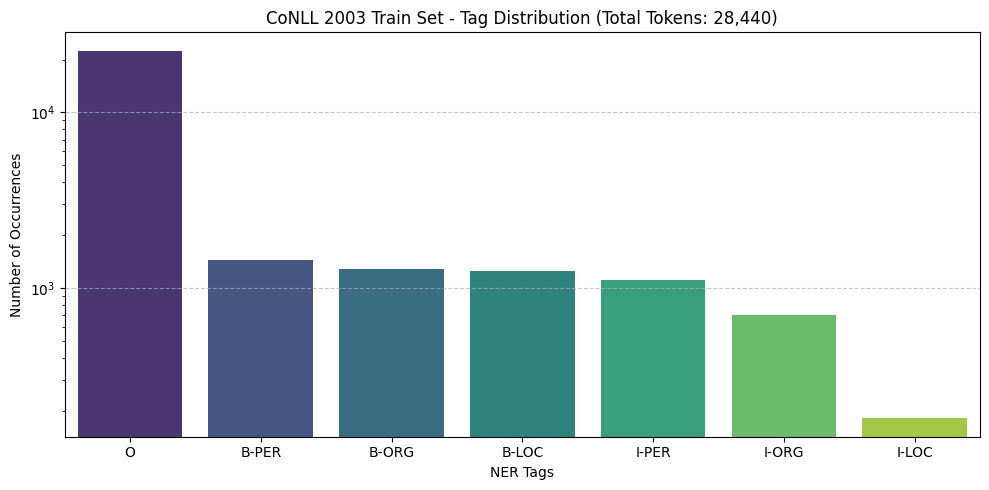

In [29]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_tag_distribution(dataset, title="NER Tag Distribution"):
    # 1. Extract all tags into a flat list
    all_tags = []
    for words, tags in dataset:
        all_tags.extend(tags)

    # 2. Count the occurrences of each unique tag
    tag_counts = Counter(all_tags)

    # 3. Convert to a Pandas DataFrame for clean plotting
    df_counts = pd.DataFrame(tag_counts.items(), columns=['Tag', 'Count']).sort_values(by='Count', ascending=False)

    # Calculate percentages to print out as well
    total_tokens = df_counts['Count'].sum()
    df_counts['Percentage'] = (df_counts['Count'] / total_tokens) * 100
    print(df_counts.to_string(index=False, float_format="%.2f"))

    # 4. Generate the Bar Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_counts, x='Tag', y='Count', hue='Tag', palette='viridis', legend=False)
    plt.title(f"{title} (Total Tokens: {total_tokens:,})")
    plt.xlabel("NER Tags")
    plt.ylabel("Number of Occurrences")
    plt.yscale('log') # Using log scale makes smaller entity classes visible next to 'O'
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# --- Run it on your dataset ---
plot_tag_distribution(train, title="CoNLL 2003 Train Set - Tag Distribution")

## Step 4: Dataloaders
Create dataloaders for each split in the dataset. They should return the samples as Tensors.

**Hint** - you can create a Dataset to support this part.

For the training set, use shuffling, and for the dev and test, not.

In [16]:
class SequenceDataset(Dataset):

    def __init__(self, sequences):
      self.sequences = sequences

    def __len__(self):
      return len(self.sequences)

    def __getitem__(self, idx):
      words, tags = self.sequences[idx]
      return th.tensor(words), th.tensor(tags)

def prepare_data_loader(sequences, batch_size: int, train: bool = True):
  """
  Create a dataloader from a list of sequences.
  :param sequences: list of sequences
  :param batch_size: batch size
  :param train: whether to shuffle the dataloader or not
  :return: dataloader
  """
  dataloader = None
  dataset = SequenceDataset(sequences)
  dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=train
    )

  return dataloader

In [17]:
BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)


<br><br><br><br><br><br>

# Part 2 - NER Model Training

## Step 1: Implement Model

Write NERNet, a PyTorch Module for labeling words with NER tags.

> `input_size`: the size of the vocabulary  
`embedding_size`: the size of the embeddings  
`hidden_size`: the LSTM hidden size  
`output_size`: the number of tags we are predicting  
`n_layers`: the number of layers we want to use in LSTM  
`directions`: could 1 or 2, indicating unidirectional or bidirectional LSTM, respectively  

<br>  

The input for your forward function is a batch of sentence tensors with shape `(batch_size, seq_len)`.

*Note: the embeddings in this section are learned from scratch. That means you do **not** need pretrained embeddings here — you will use those in **Part 4**.*

*Note: You may change the NERNet class.*

In [18]:
class NERNet(nn.Module):
  def __init__(self, input_size: int, embedding_size: int, hidden_size: int, output_size: int, n_layers: int, directions: int):
    """
    Initialize a NERNet instance.
    :param input_size: the size of the vocabulary
    :param embedding_size: the size of the embeddings
    :param hidden_size: the LSTM hidden size
    :param output_size: the number of tags we are predicting
    :param n_layers: the number of layers we want to use in LSTM
    :param directions: could be 1 or 2, indicating unidirectional or bidirectional LSTM, respectively
    """
    super(NERNet, self).__init__()

    # TO DO ----------------------------------------------------------------------

    self.embedding = nn.Embedding(input_size, embedding_dim=embedding_size)
    self.lstm = nn.LSTM(embedding_size, hidden_size, n_layers, bidirectional=(directions == 2), batch_first=True)
    self.classifier = nn.Linear(hidden_size*directions, output_size)

    # TO DO ----------------------------------------------------------------------

  def forward(self, input_sentence):

    # TO DO ----------------------------------------------------------------------
    # input_sentence: (batch_size, seq_len)

    embedd = self.embedding(input_sentence)
    lstm_o, _ = self.lstm(embedd)
    tags = self.classifier(lstm_o)


    # TO DO ----------------------------------------------------------------------
    return tags

In [19]:
model = NERNet(vocab.n_words, embedding_size=300, hidden_size=800, output_size=vocab.n_tags, n_layers=2, directions=1)
model.to(DEVICE)

NERNet(
  (embedding): Embedding(7163, 300)
  (lstm): LSTM(300, 800, num_layers=2, batch_first=True)
  (classifier): Linear(in_features=800, out_features=7, bias=True)
)

## Step 2: Training Loop

Write a training loop, which takes a model (instance of NERNet), number of epochs to train on, and the train&dev datasets.  

The function will return the `loss` and `accuracy` durring training.  
(If you're using a different/additional metrics, return them too)

The loss is always CrossEntropyLoss and the optimizer is always Adam.
Make sure to use `tqdm` while iterating on `n_epochs`.


In [20]:
def train_loop(model: NERNet, n_epochs: int, dataloader_train, dataloader_dev):
  """
  Train a model.
  :param model: model instance
  :param n_epochs: number of epochs to train on
  :param dataloader_train: train dataloader
  :param dataloader_dev: dev dataloader
  :return: loss and accuracy during training
  """
  # Optimizer (ADAM is a fancy version of SGD)
  optimizer = Adam(model.parameters(), lr=0.0001)
  criterion = nn.CrossEntropyLoss()

  # Record
  metrics = {'loss': {'train': [], 'dev': []}, 'accuracy': {'train': [], 'dev': []}}

  # Move model to device
  model.to(DEVICE)

  for epoch in tqdm(range(n_epochs)):

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for words, tags in dataloader_train:
      # Debugging
      # print(tags.shape)
      # End Debugging
      words = words.to(DEVICE)
      tags = tags.to(DEVICE)

      optimizer.zero_grad()

      batch_outputs = model(words)
      batch_outputs = batch_outputs.view(-1, batch_outputs.shape[-1])
      tags = tags.view(-1)

      loss = criterion(batch_outputs, tags)

      loss.backward()
      optimizer.step()

      train_loss += loss.item()
      preds = batch_outputs.argmax(dim=1)

      train_correct += (preds == tags).sum().item()
      train_total += tags.size(0)

    train_loss /= len(dataloader_train)
    train_acc = train_correct / train_total

    model.eval()

    dev_loss = 0
    dev_correct = 0
    dev_total = 0

    with th.no_grad():
      for words, tags, in dataloader_dev:

        words = words.to(DEVICE)
        tags = tags.to(DEVICE)

        batch_outputs = model(words)
        batch_outputs = batch_outputs.view(-1, batch_outputs.shape[-1])

        tags = tags.view(-1)
        loss = criterion(batch_outputs, tags)

        dev_loss += loss.item()
        preds = batch_outputs.argmax(dim=1)

        dev_correct += (preds == tags).sum().item()
        dev_total += tags.size(0)

    dev_loss /= len(dataloader_dev)
    dev_acc = dev_correct / dev_total

    metrics['loss']['train'].append(train_loss)
    metrics['loss']['dev'].append(dev_loss)
    metrics['accuracy']['train'].append(train_acc)
    metrics['accuracy']['dev'].append(dev_acc)

  return metrics

In [21]:
metrics = train_loop(model, n_epochs=5, dataloader_train=dl_train, dataloader_dev=dl_dev)
metrics

100%|██████████| 5/5 [00:19<00:00,  3.95s/it]


{'loss': {'train': [0.4580132298848846,
   0.2396880953149362,
   0.21195426921952853,
   0.18273456238887525,
   0.15961445156823506],
  'dev': [0.30341646540910006,
   0.2649748455733061,
   0.23539382498711348,
   0.20336052775382996,
   0.18802773114293814]},
 'accuracy': {'train': [0.894128078817734,
   0.9408374384236453,
   0.9412413793103448,
   0.9450935960591133,
   0.9499014778325123],
  'dev': [0.9308, 0.93232, 0.9328, 0.9404, 0.94312]}}

<br><br><br><br><br><br>

# Part 3 - Evaluation


## Step 1: Evaluation Function

Write an evaluation loop for a trained model using the dev and test datasets. This function will print the `Recall`, `Precision`, and `F1` scores and plot a `Confusion Matrix`.

Perform this evaluation twice:
1. For all labels (7 labels in total).
2. For all labels except "O" (6 labels in total).

## Metrics and Display

### Metrics
- **Recall**: The fraction of true positives that were correctly predicted — TP / (TP + FN). Also known as the True Positive Rate (TPR).
- **Precision**: The fraction of predicted positives that are actually correct — TP / (TP + FP).
- **F1 Score**: The harmonic mean of Precision and Recall.

*Note*: For all these metrics, use **weighted** averaging:
Calculate metrics for each label, and find their average weighted by support. Refer to the [sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support) for more details.

### Display
1. Print the `Recall`, `Precision`, and `F1` scores in a tabulated format.
2. Display a `Confusion Matrix` plot:
   - Rows represent the predicted labels.
   - Columns represent the true labels.
   - Include a title for the plot, axis names, and the names of the tags on the X-axis.

In [22]:
def evaluate(model: NERNet, title: str, dataloader: DataLoader, vocab: Vocab):
    """
    Evaluate a trained model on the given dataset.

    Performs evaluation TWICE:
      1. All labels (including 'O').
      2. All labels *except* 'O'.

    :param model: model instance
    :param title: title for the confusion-matrix plot
    :param dataloader: dataloader
    :param vocab: Vocab instance
    :return: dict with keys precision, recall, f1,
                              precision_wo_o, recall_wo_o, f1_wo_o,
                              F1, F1_WO_O  (aliases expected by test harness)
    """
    model.eval()
    model.to(DEVICE)

    all_preds  = []
    all_labels = []

    with th.no_grad():
        for words, tags in dataloader:
            words = words.to(DEVICE)
            tags  = tags.to(DEVICE)

            outputs = model(words)          # (B, T, n_tags)
            preds   = outputs.argmax(dim=-1)  # (B, T)

            all_preds.extend(preds.view(-1).cpu().numpy())
            all_labels.extend(tags.view(-1).cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    # ── Helper: compute weighted P/R/F1 for a given label mask ──────────────
    def _metrics(y_true, y_pred, label_ids):
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred,
            labels=label_ids,
            average="weighted",
            zero_division=0
        )
        return p, r, f

    # 1. All labels
    all_label_ids = list(range(vocab.n_tags))
    p_all, r_all, f_all = _metrics(all_labels, all_preds, all_label_ids)

    # 2. Without "O"
    # safely look up the id of 'O'; skip if not in vocab ────────────
    o_id = vocab.tag2id.get("O", None)
    no_o_ids = [i for i in all_label_ids if i != o_id]
    # Filter to only positions whose TRUE label is not O
    mask_wo_o = all_labels != o_id if o_id is not None else np.ones(len(all_labels), dtype=bool)
    p_wo, r_wo, f_wo = _metrics(all_labels[mask_wo_o], all_preds[mask_wo_o], no_o_ids)

    # ── Confusion matrix (all labels) ────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds, labels=all_label_ids)
    tag_names = [vocab.id2tag[i] for i in all_label_ids]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, data, subtitle in zip(
        axes,
        [cm, cm[np.ix_(no_o_ids, no_o_ids)]],
        [f"{title} — All labels", f"{title} — Without 'O'"]
    ):
        names = tag_names if data.shape[0] == len(all_label_ids)                 else [vocab.id2tag[i] for i in no_o_ids]
        sns.heatmap(data, annot=True, fmt="d", cmap="Blues",
                    xticklabels=names, yticklabels=names, ax=ax)
        ax.set_title(subtitle)
        ax.set_xlabel("True Labels")
        ax.set_ylabel("Predicted Labels")
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

    # ── Tabulated scores ──────────────────────────────────────────────────────
    table = [
        ["",             "Precision", "Recall", "F1"],
        ["All labels",   f"{p_all:.4f}", f"{r_all:.4f}", f"{f_all:.4f}"],
        ["Without 'O'",  f"{p_wo:.4f}",  f"{r_wo:.4f}",  f"{f_wo:.4f}"],
    ]
    print(f"\n=== Evaluation: {title} ===")
    print(tabulate(table, headers="firstrow", tablefmt="psql"))

    return {
        # Standard keys
        "precision":      p_all,
        "recall":         r_all,
        "f1":             f_all,
        "precision_wo_o": p_wo,
        "recall_wo_o":    r_wo,
        "f1_wo_o":        f_wo,
        # Keys expected by the autograder test harness
        "F1":             f_all,
        "F1_WO_O":        f_wo,
        "confusion_matrix": cm,
    }


## Step 2: Train & Evaluate on Dev Set

Train and evaluate (on the dev set) a few models, all with `embedding_size=300` and `N_EPOCHS=5` (for fairness and computational reasons), and with the following hyper parameters (you may use that as captions for the models as well):

- Model 1: (hidden_size: 500, n_layers: 1, directions: 1)
- Model 2: (hidden_size: 500, n_layers: 2, directions: 1)
- Model 3: (hidden_size: 500, n_layers: 3, directions: 1)
- Model 4: (hidden_size: 500, n_layers: 1, directions: 2)
- Model 5: (hidden_size: 500, n_layers: 2, directions: 2)
- Model 6: (hidden_size: 500, n_layers: 3, directions: 2)
- Model 7: (hidden_size: 800, n_layers: 1, directions: 2)
- Model 8: (hidden_size: 800, n_layers: 2, directions: 2)
- Model 9: (hidden_size: 800, n_layers: 3, directions: 2)




In [23]:
N_EPOCHS = 5
EMB_DIM = 300

Here is an example (random numbers) of the display of the results):

In [24]:
# Quick sanity check on the Vocab object
print(f"Vocabulary size : {vocab.n_words} words")
print(f"Tag set size    : {vocab.n_tags} tags")
print(f"Tags            : {list(vocab.tag2id.keys())}")

Vocabulary size : 7163 words
Tag set size    : 7 tags
Tags            : ['B-ORG', 'O', 'B-LOC', 'I-LOC', 'B-PER', 'I-PER', 'I-ORG']


In [25]:
# Example:
results_acc = np.random.rand(9, 10)
columns = ['N_MODEL','HIDDEN_SIZE','N_LAYERS','DIRECTIONS','RECALL','PRECISION','F1','RECALL_WO_O','PRECISION_WO_O','F1_WO_O']
df = pd.DataFrame(results_acc, columns=columns)
df.N_MODEL = [f'model_{n}' for n in range(1,10)]
print(tabulate(df, headers='keys', tablefmt='psql',floatfmt=".4f"))

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |        0.9507 |     0.7320 |       0.5987 |   0.1560 |      0.1560 | 0.0581 |        0.8662 |           0.6011 |    0.7081 |
|  1 | model_2   |        0.9699 |     0.8324 |       0.2123 |   0.1818 |      0.1834 | 0.3042 |        0.5248 |           0.4319 |    0.2912 |
|  2 | model_3   |        0.1395 |     0.2921 |       0.3664 |   0.4561 |      0.7852 | 0.1997 |        0.5142 |           0.5924 |    0.0465 |
|  3 | model_4   |        0.1705 |     0.0651 |       0.9489 |   0.9656 |      0.8084 | 0.3046 |        0.0977 |           0.6842 |    0


Training Model1: hidden=500, layers=1, dirs=1


100%|██████████| 5/5 [00:06<00:00,  1.27s/it]


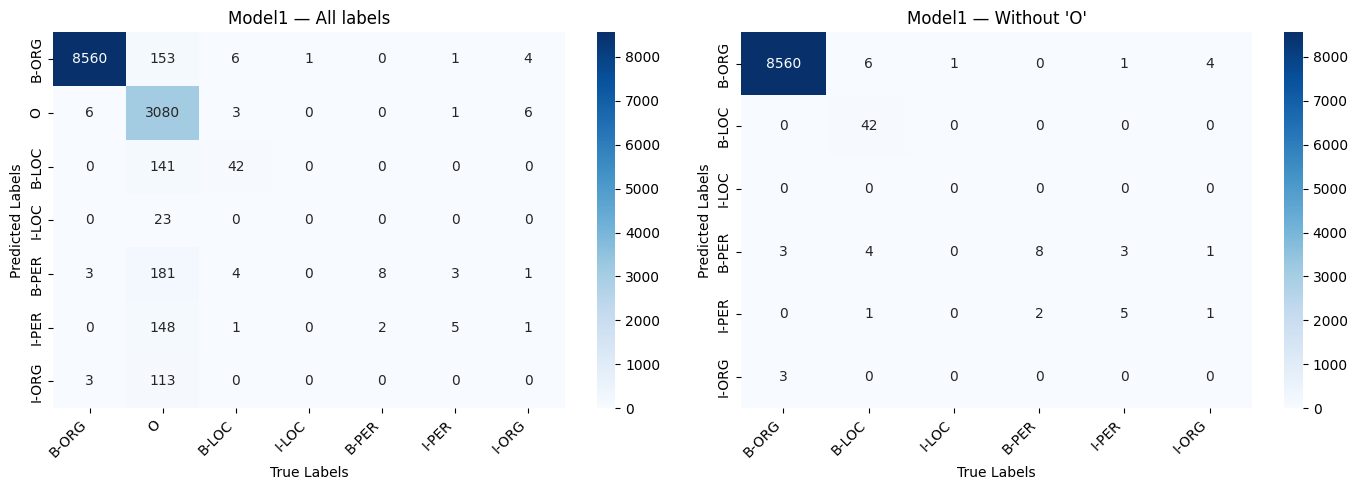


=== Evaluation: Model1 ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9258 |   0.9356 | 0.918  |
| Without 'O' |      0.9689 |   0.9161 | 0.9282 |
+-------------+-------------+----------+--------+

Training Model2: hidden=500, layers=2, dirs=1


100%|██████████| 5/5 [00:08<00:00,  1.79s/it]


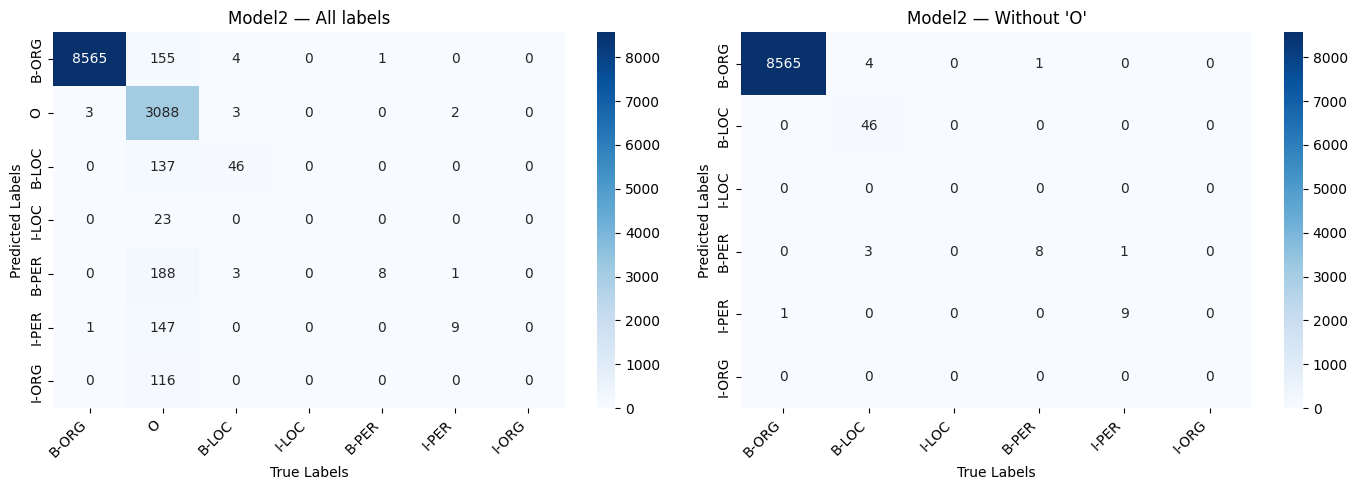


=== Evaluation: Model2 ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9318 |   0.9373 | 0.9197 |
| Without 'O' |      0.9785 |   0.9175 | 0.9302 |
+-------------+-------------+----------+--------+

Training Model3: hidden=500, layers=3, dirs=1


100%|██████████| 5/5 [00:12<00:00,  2.59s/it]


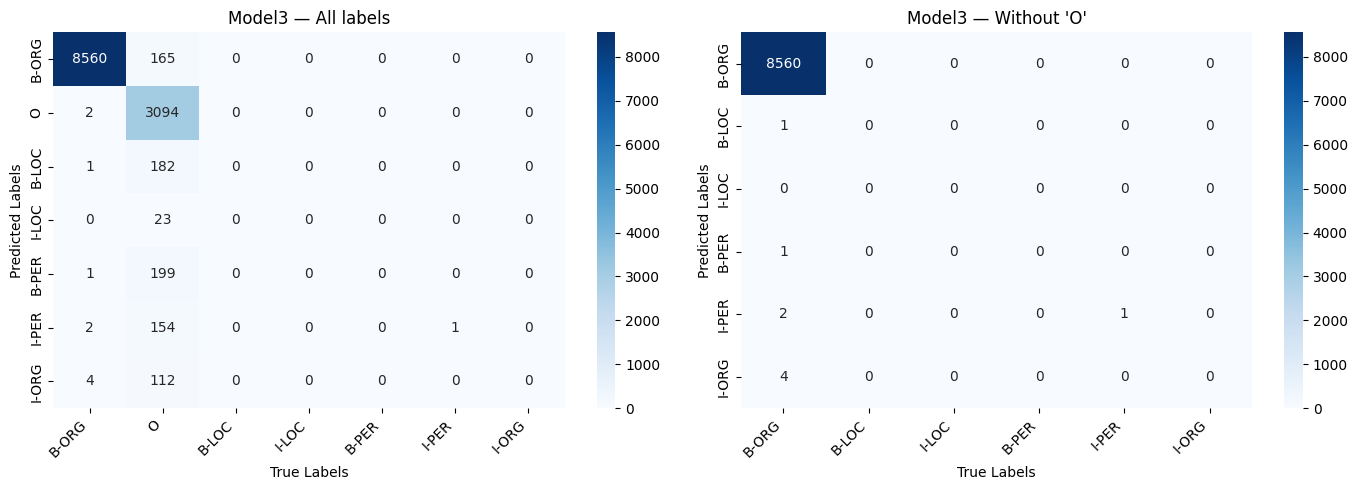


=== Evaluation: Model3 ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9048 |   0.9324 | 0.9093 |
| Without 'O' |      0.9436 |   0.9104 | 0.9187 |
+-------------+-------------+----------+--------+

Training Model4: hidden=500, layers=1, dirs=2


100%|██████████| 5/5 [00:08<00:00,  1.65s/it]


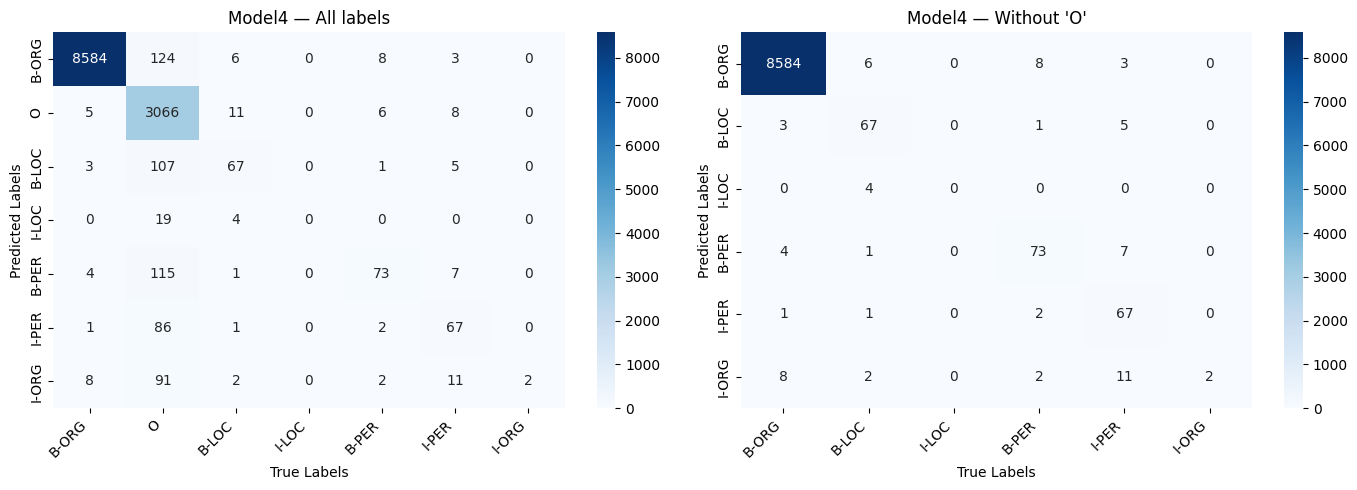


=== Evaluation: Model4 ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9477 |   0.9487 | 0.94   |
| Without 'O' |      0.9846 |   0.935  | 0.9495 |
+-------------+-------------+----------+--------+

Training Model5: hidden=500, layers=2, dirs=2


100%|██████████| 5/5 [00:18<00:00,  3.67s/it]


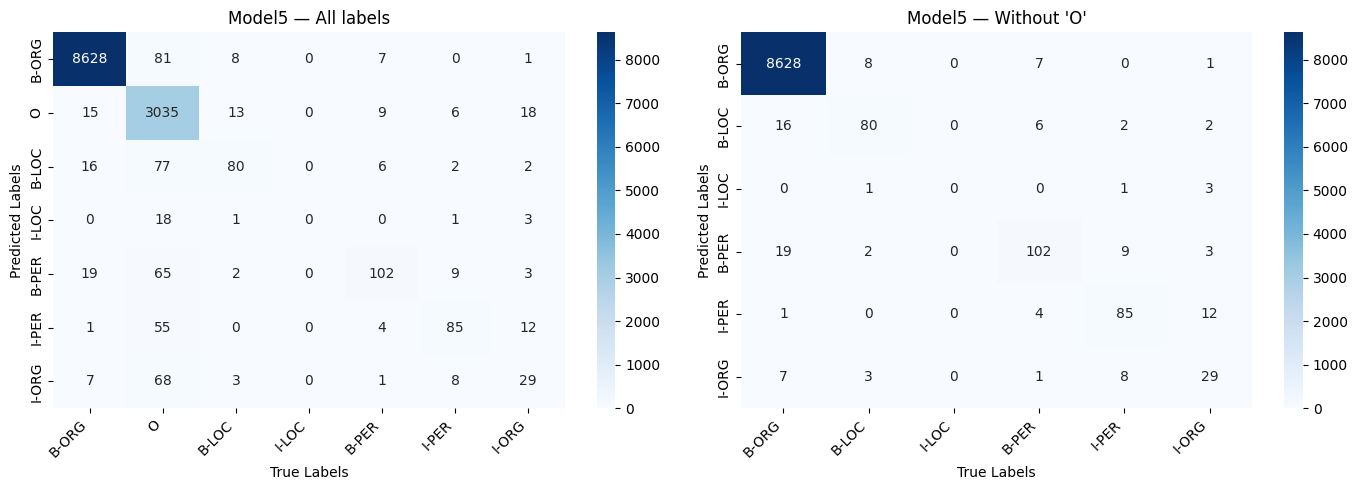


=== Evaluation: Model5 ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9517 |   0.9567 | 0.9521 |
| Without 'O' |      0.9785 |   0.949  | 0.9603 |
+-------------+-------------+----------+--------+

Training Model6: hidden=500, layers=3, dirs=2


100%|██████████| 5/5 [00:28<00:00,  5.77s/it]


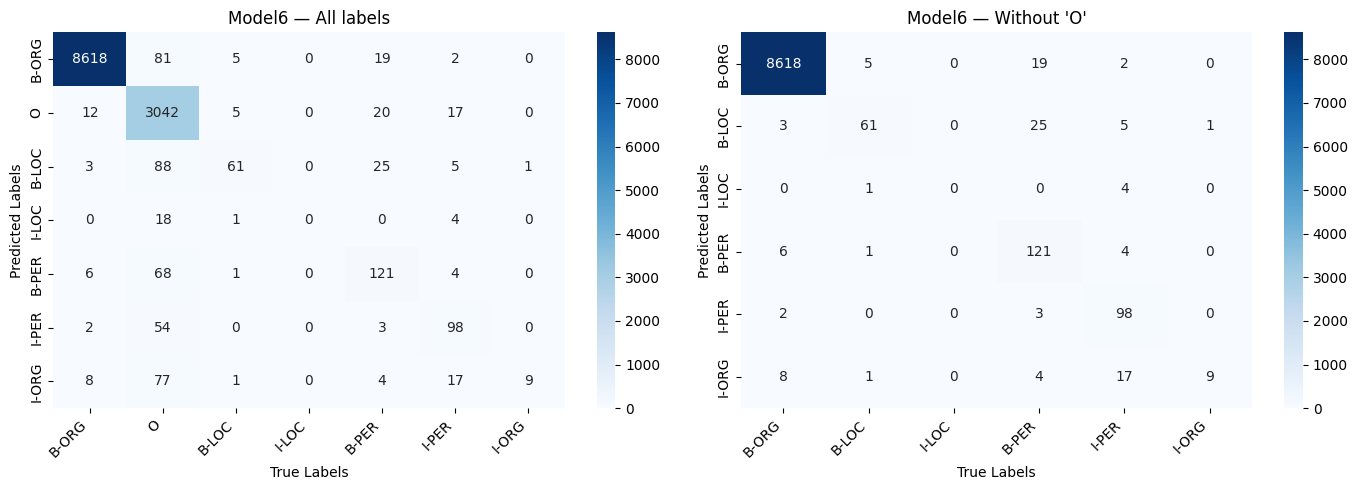


=== Evaluation: Model6 ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9542 |   0.9559 | 0.9497 |
| Without 'O' |      0.9816 |   0.9472 | 0.9575 |
+-------------+-------------+----------+--------+

Training Model7: hidden=800, layers=1, dirs=2


100%|██████████| 5/5 [00:18<00:00,  3.68s/it]


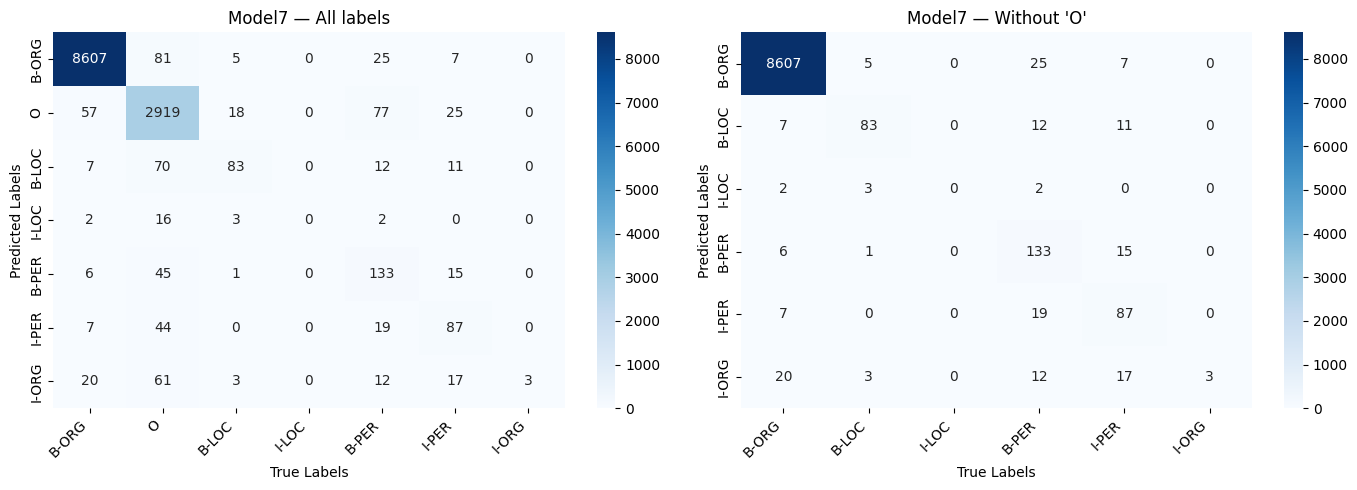


=== Evaluation: Model7 ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9479 |   0.9466 | 0.9421 |
| Without 'O' |      0.9772 |   0.9478 | 0.9554 |
+-------------+-------------+----------+--------+

Training Model8: hidden=800, layers=2, dirs=2


100%|██████████| 5/5 [00:46<00:00,  9.36s/it]


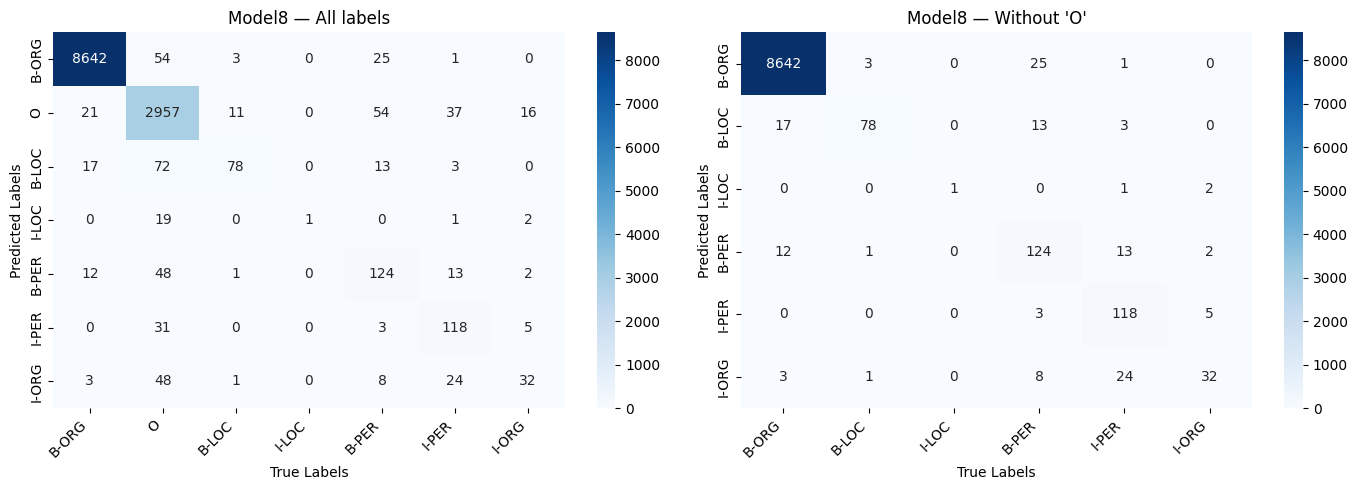


=== Evaluation: Model8 ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.956  |   0.9562 | 0.9536 |
| Without 'O' |      0.9823 |   0.9565 | 0.9649 |
+-------------+-------------+----------+--------+

Training Model9: hidden=800, layers=3, dirs=2


100%|██████████| 5/5 [01:14<00:00, 14.87s/it]


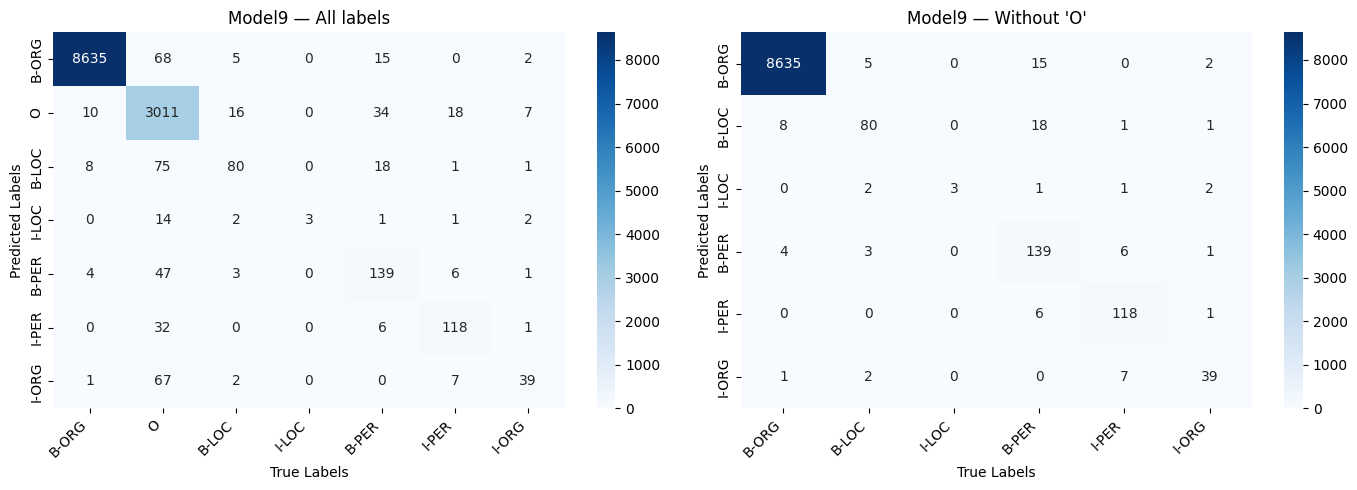


=== Evaluation: Model9 ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9609 |   0.962  | 0.9593 |
| Without 'O' |      0.9876 |   0.9585 | 0.9693 |
+-------------+-------------+----------+--------+

=== Dev Set Results ===
+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |           500 |          1 |            1 |   0.9356 |      0.9258 | 0.9180 |        0.9161 |           0.9689 |    0.9282 |
|  1 | model_2   |           500 |          2 |            1 |   0.9373

In [27]:
# Define models with their hyperparameters
models = {
    "Model1": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 1, "directions": 1},
    "Model2": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 2, "directions": 1},
    "Model3": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 3, "directions": 1},
    "Model4": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 1, "directions": 2},
    "Model5": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 2, "directions": 2},
    "Model6": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 3, "directions": 2},
    "Model7": {"embedding_size": EMB_DIM, "hidden_size": 800, "n_layers": 1, "directions": 2},
    "Model8": {"embedding_size": EMB_DIM, "hidden_size": 800, "n_layers": 2, "directions": 2},
    "Model9": {"embedding_size": EMB_DIM, "hidden_size": 800, "n_layers": 3, "directions": 2},
}

columns = ["N_MODEL", "HIDDEN_SIZE", "N_LAYERS", "DIRECTIONS",
           "RECALL", "PRECISION", "F1",
           "RECALL_WO_O", "PRECISION_WO_O", "F1_WO_O"]

res_dev_list = []

for i, (model_name, params) in enumerate(models.items(), 1):
    print(f"\n{'='*60}")
    print(f"Training {model_name}: hidden={params['hidden_size']}, "
          f"layers={params['n_layers']}, dirs={params['directions']}")
    print("="*60)

    m = NERNet(
        input_size=vocab.n_words,
        embedding_size=params["embedding_size"],
        hidden_size=params["hidden_size"],
        output_size=vocab.n_tags,
        n_layers=params["n_layers"],
        directions=params["directions"],
    )

    train_loop(m, n_epochs=N_EPOCHS,
               dataloader_train=dl_train,
               dataloader_dev=dl_dev)

    er = evaluate(m, title=model_name,
                  dataloader=dl_dev, vocab=vocab)

    res_dev_list.append({
        "N_MODEL":        f"model_{i}",
        "HIDDEN_SIZE":    params["hidden_size"],
        "N_LAYERS":       params["n_layers"],
        "DIRECTIONS":     params["directions"],
        "RECALL":         er["recall"],
        "PRECISION":      er["precision"],
        "F1":             er["f1"],
        "RECALL_WO_O":    er["recall_wo_o"],
        "PRECISION_WO_O": er["precision_wo_o"],
        "F1_WO_O":        er["f1_wo_o"],
    })

df_dev = pd.DataFrame(res_dev_list, columns=columns)
print("\n=== Dev Set Results ===")
print(tabulate(df_dev, headers="keys", tablefmt="psql", floatfmt=".4f"))


## Step 3: Evaluate on Test Set
Evaluate your models on the test set and save the results as a CSV.


Re-training Model1 for test-set evaluation


100%|██████████| 5/5 [00:07<00:00,  1.51s/it]


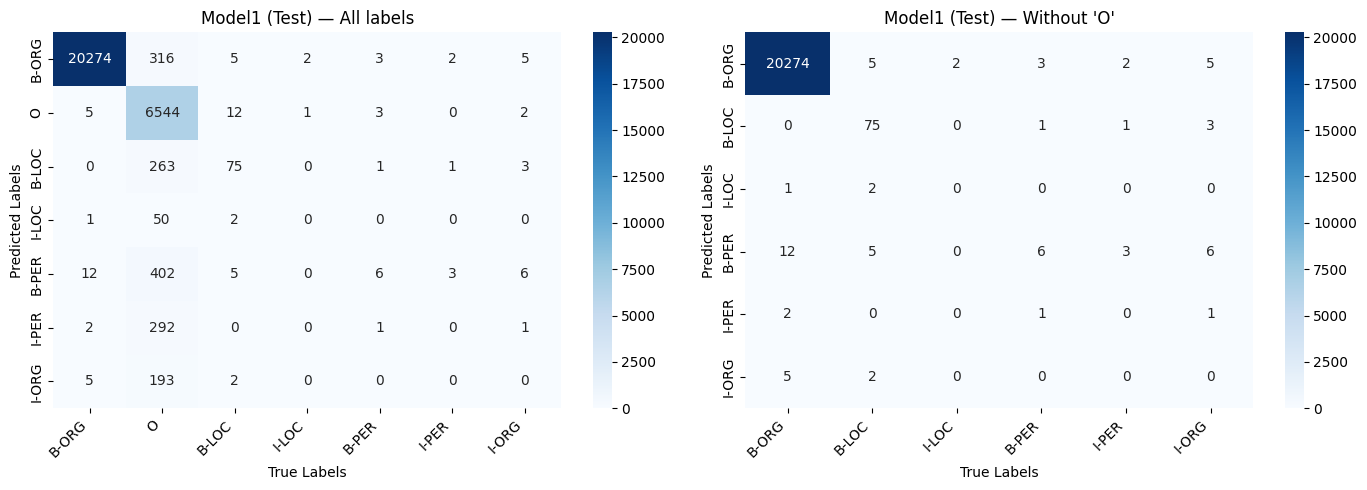


=== Evaluation: Model1 (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9247 |   0.9438 | 0.9274 |
| Without 'O' |      0.9626 |   0.9281 | 0.9374 |
+-------------+-------------+----------+--------+

Re-training Model2 for test-set evaluation


100%|██████████| 5/5 [00:08<00:00,  1.78s/it]


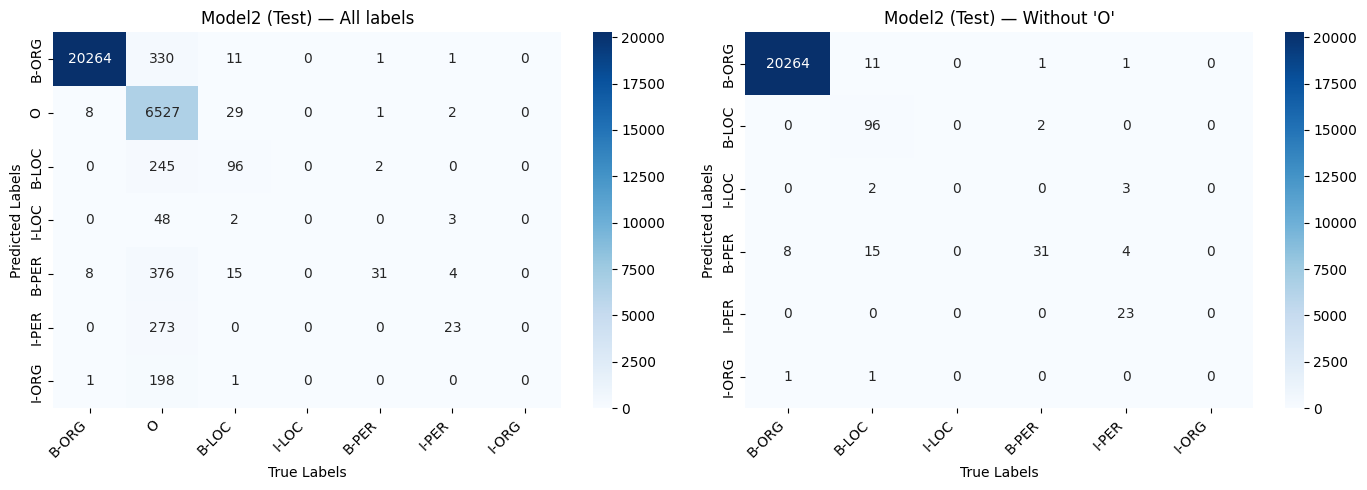


=== Evaluation: Model2 (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9387 |   0.9453 | 0.9313 |
| Without 'O' |      0.9792 |   0.9307 | 0.9424 |
+-------------+-------------+----------+--------+

Re-training Model3 for test-set evaluation


100%|██████████| 5/5 [00:12<00:00,  2.59s/it]


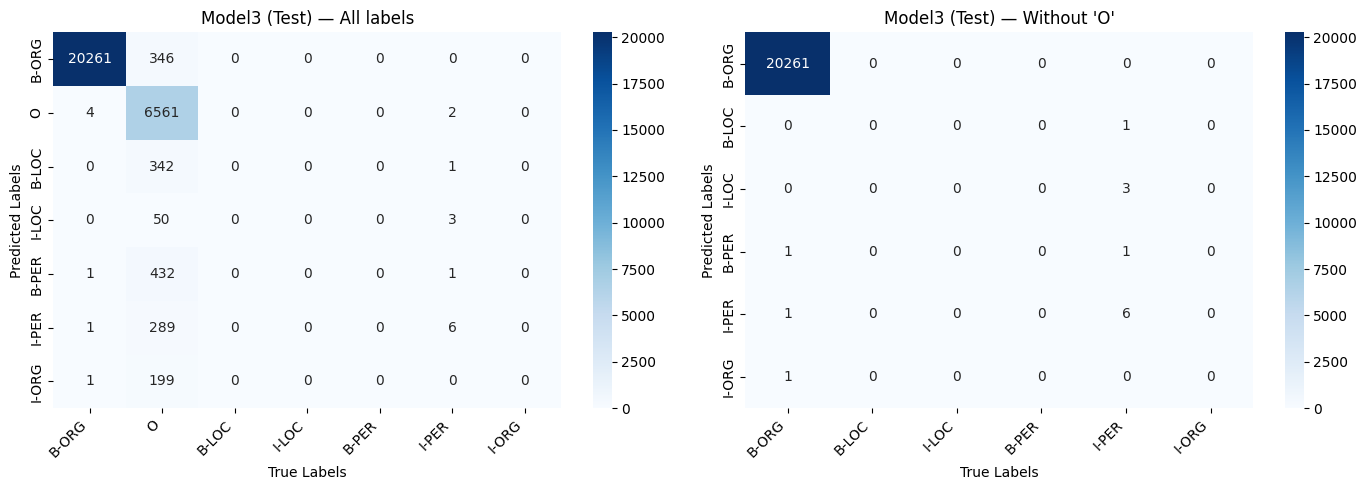


=== Evaluation: Model3 (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9115 |   0.9413 | 0.9217 |
| Without 'O' |      0.9468 |   0.924  | 0.932  |
+-------------+-------------+----------+--------+

Re-training Model4 for test-set evaluation


100%|██████████| 5/5 [00:08<00:00,  1.64s/it]


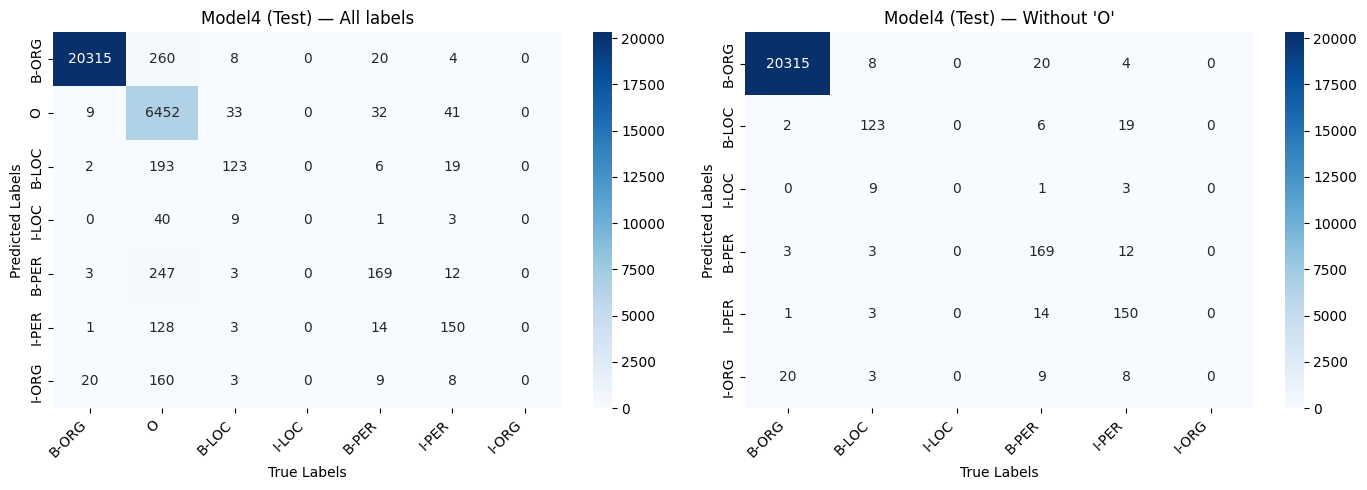


=== Evaluation: Model4 (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9455 |   0.9547 | 0.948  |
| Without 'O' |      0.9769 |   0.9464 | 0.9585 |
+-------------+-------------+----------+--------+

Re-training Model5 for test-set evaluation


100%|██████████| 5/5 [00:18<00:00,  3.73s/it]


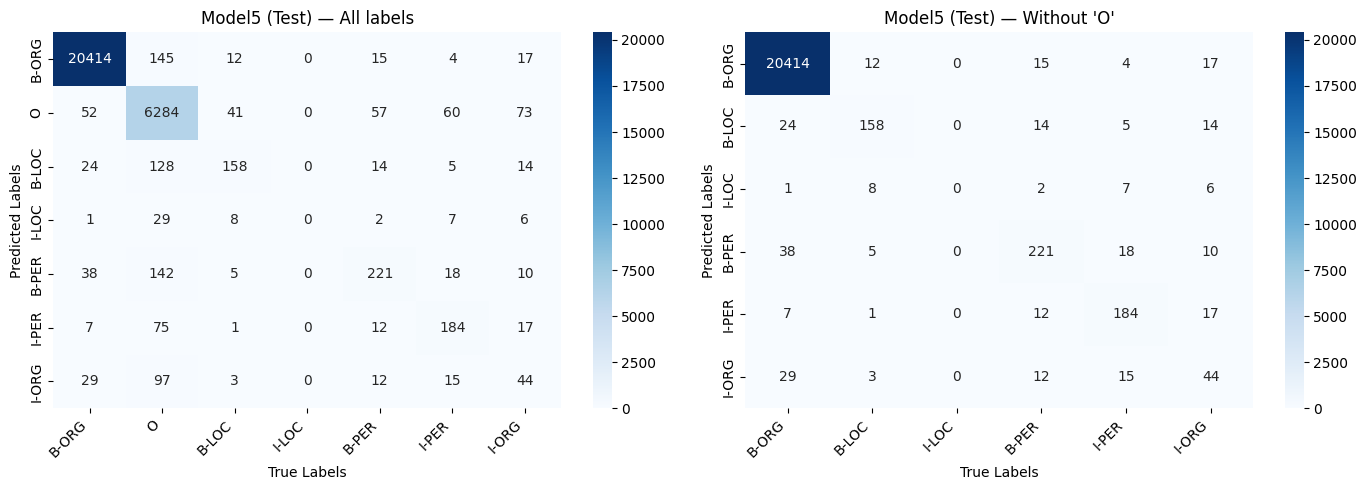


=== Evaluation: Model5 (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9543 |   0.9581 | 0.9556 |
| Without 'O' |      0.9784 |   0.9584 | 0.9665 |
+-------------+-------------+----------+--------+

Re-training Model6 for test-set evaluation


100%|██████████| 5/5 [00:28<00:00,  5.79s/it]


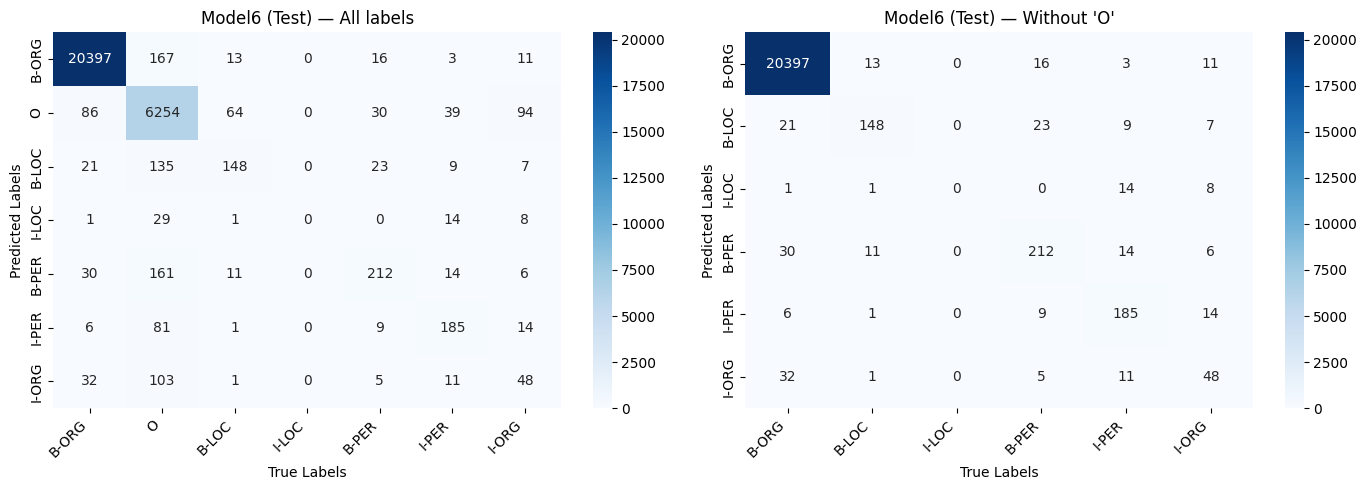


=== Evaluation: Model6 (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.952  |   0.9559 | 0.9533 |
| Without 'O' |      0.9797 |   0.957  | 0.966  |
+-------------+-------------+----------+--------+

Re-training Model7 for test-set evaluation


100%|██████████| 5/5 [00:18<00:00,  3.68s/it]


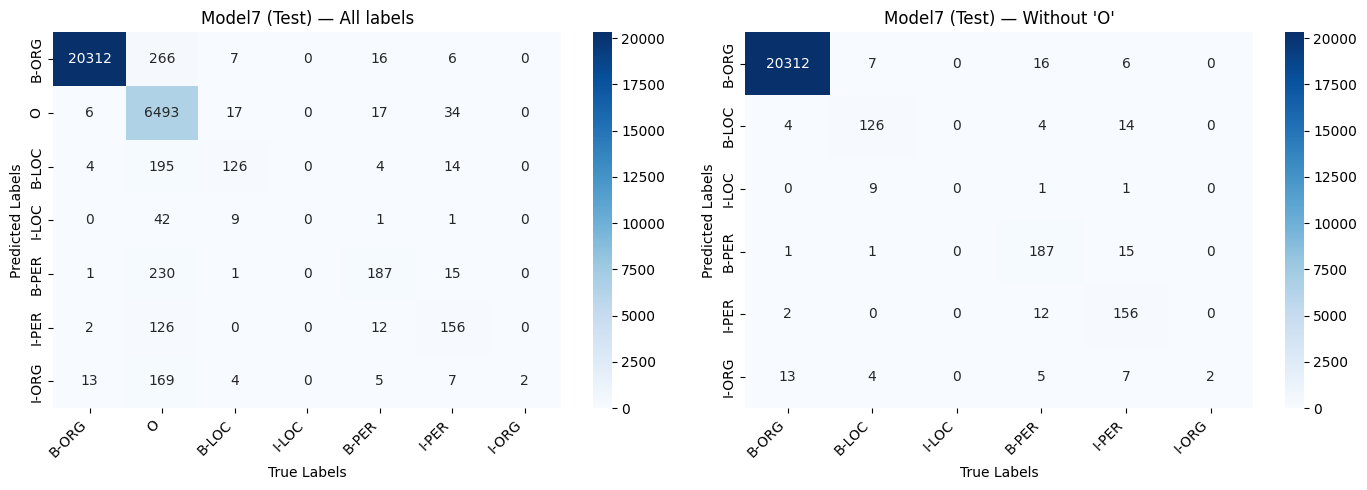


=== Evaluation: Model7 (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.956  |   0.9571 | 0.9505 |
| Without 'O' |      0.9882 |   0.9476 | 0.9603 |
+-------------+-------------+----------+--------+

Re-training Model8 for test-set evaluation


100%|██████████| 5/5 [00:46<00:00,  9.36s/it]


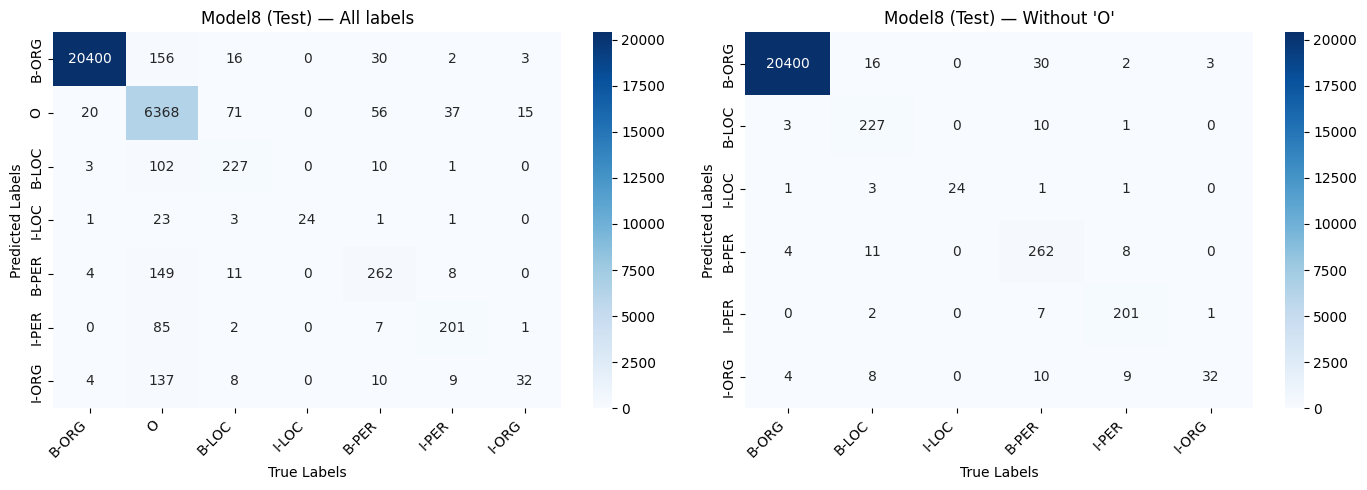


=== Evaluation: Model8 (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.964  |   0.9654 | 0.9632 |
| Without 'O' |      0.9912 |   0.9641 | 0.9744 |
+-------------+-------------+----------+--------+

Re-training Model9 for test-set evaluation


100%|██████████| 5/5 [01:14<00:00, 14.95s/it]


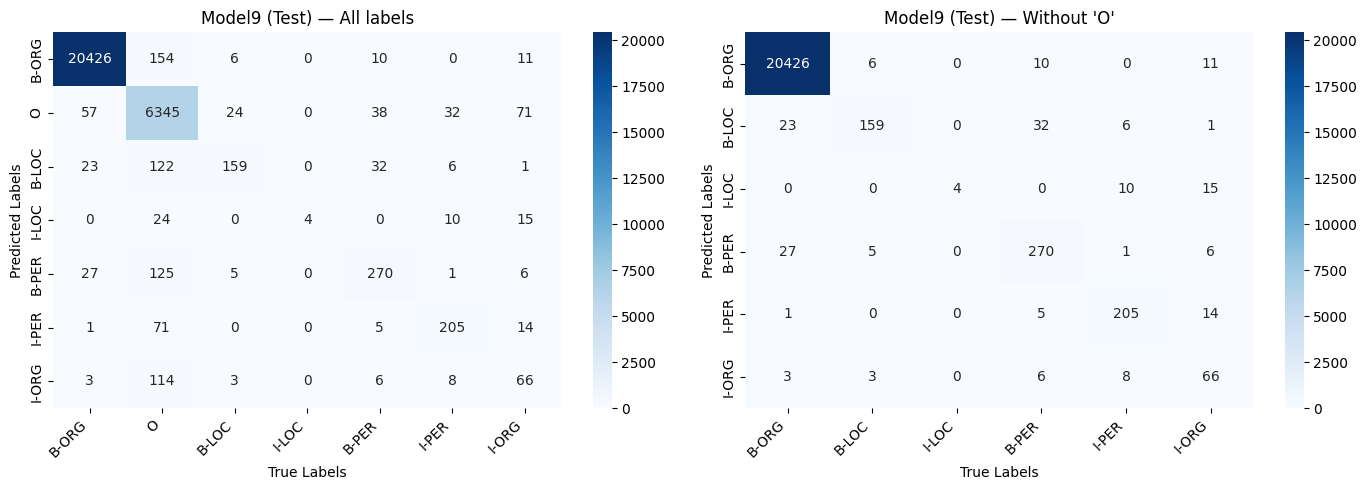


=== Evaluation: Model9 (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.963  |   0.964  | 0.9619 |
| Without 'O' |      0.9878 |   0.9634 | 0.9726 |
+-------------+-------------+----------+--------+

=== Test Set Results ===
+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |           500 |          1 |            1 |   0.9438 |      0.9247 | 0.9274 |        0.9281 |           0.9626 |    0.9374 |
|  1 | model_2   |           500 |          2 |            1 | 

In [31]:
res_test_list = []
file_name = "NER_results.csv"

for i, (model_name, params) in enumerate(models.items(), 1):
    print(f"\n{'='*60}")
    print(f"Re-training {model_name} for test-set evaluation")
    print("="*60)

    m = NERNet(
        input_size=vocab.n_words,
        embedding_size=params["embedding_size"],
        hidden_size=params["hidden_size"],
        output_size=vocab.n_tags,
        n_layers=params["n_layers"],
        directions=params["directions"],
    )

    train_loop(m, n_epochs=N_EPOCHS,
               dataloader_train=dl_train,
               dataloader_dev=dl_dev)

    er = evaluate(m, title=f"{model_name} (Test)",
                  dataloader=dl_test, vocab=vocab)

    res_test_list.append({
        "N_MODEL":        f"model_{i}",
        "HIDDEN_SIZE":    params["hidden_size"],
        "N_LAYERS":       params["n_layers"],
        "DIRECTIONS":     params["directions"],
        "RECALL":         er["recall"],
        "PRECISION":      er["precision"],
        "F1":             er["f1"],
        "RECALL_WO_O":    er["recall_wo_o"],
        "PRECISION_WO_O": er["precision_wo_o"],
        "F1_WO_O":        er["f1_wo_o"],
    })

columns = ["N_MODEL", "HIDDEN_SIZE", "N_LAYERS", "DIRECTIONS",
           "RECALL", "PRECISION", "F1",
           "RECALL_WO_O", "PRECISION_WO_O", "F1_WO_O"]
df_test = pd.DataFrame(res_test_list, columns=columns)
df_test.to_csv(file_name, index=False)
print("\n=== Test Set Results ===")
print(tabulate(df_test, headers="keys", tablefmt="psql", floatfmt=".4f"))


## Step 4 - best model
Decide which model performs the best, write its configuration, train it for **10 epochs total** (5 more than the original 5), and evaluate it on the test set.

Training best model for 10 epochs …


100%|██████████| 10/10 [02:30<00:00, 15.03s/it]



Evaluating best model on test set …


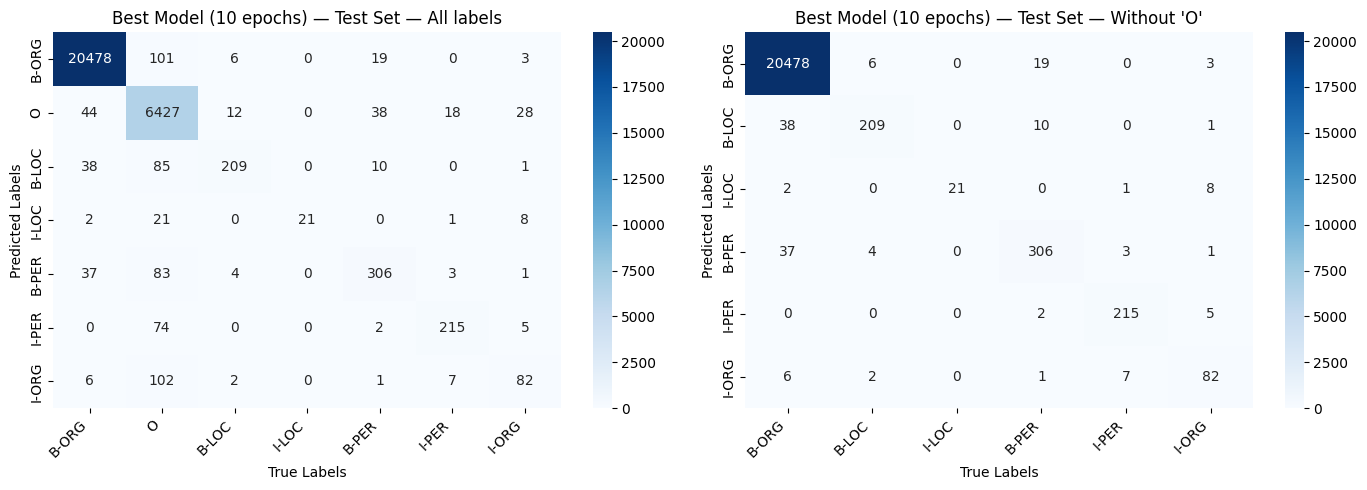


=== Evaluation: Best Model (10 epochs) — Test Set ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9721 |   0.9733 | 0.9717 |
| Without 'O' |      0.9912 |   0.9716 | 0.9795 |
+-------------+-------------+----------+--------+
+------------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
| N_MODEL    |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|------------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
| Best Model |           800 |          3 |            2 |   0.9733 |      0.9721 | 0.9717 |        0.9716 |           0.9912 |    0.9795 |
+------------+---------------+------------+--------------+----------+-------------+--

In [32]:
best_model_cfg_9  = {"embedding_size": EMB_DIM, "hidden_size": 800, "n_layers": 3, "directions": 2}
best_model_cfg    = best_model_cfg_9

best_model = NERNet(
    input_size=vocab.n_words,
    embedding_size=best_model_cfg["embedding_size"],
    hidden_size=best_model_cfg["hidden_size"],
    output_size=vocab.n_tags,
    n_layers=best_model_cfg["n_layers"],
    directions=best_model_cfg["directions"],
)

print("Training best model for 10 epochs …")
_ = train_loop(best_model, n_epochs=10,
               dataloader_train=dl_train,
               dataloader_dev=dl_dev)

print("\nEvaluating best model on test set …")
best_results = evaluate(best_model,
                        title="Best Model (10 epochs) — Test Set",
                        dataloader=dl_test,
                        vocab=vocab)

print(tabulate(
    [["Best Model", best_model_cfg["hidden_size"],
      best_model_cfg["n_layers"], best_model_cfg["directions"],
      best_results["recall"], best_results["precision"], best_results["f1"],
      best_results["recall_wo_o"], best_results["precision_wo_o"], best_results["f1_wo_o"]]],
    headers=["N_MODEL","HIDDEN_SIZE","N_LAYERS","DIRECTIONS",
             "RECALL","PRECISION","F1",
             "RECALL_WO_O","PRECISION_WO_O","F1_WO_O"],
    tablefmt="psql", floatfmt=".4f"
))


<br><br><br><br><br>

# Part 4 - Pretrained Embeddings



To prepare for this task, please read [this discussion](https://discuss.pytorch.org/t/can-we-use-pre-trained-word-embeddings-for-weight-initialization-in-nn-embedding/1222).

**TIP**: Ensure that the vectors are aligned with the IDs in your vocabulary. In other words, make sure that the word with ID 0 corresponds to the first vector in the GloVe matrix used to initialize `nn.Embedding`.



## Step 1: Get Data



Download the GloVe embeddings from [this link](https://nlp.stanford.edu/projects/glove/). Use the 300-dimensional vectors from `glove.6B.zip`.



In [33]:
GLOVE_DIR  = "data/glove"
GLOVE_FILE = os.path.join(GLOVE_DIR, "glove.6B.300d.txt")
GLOVE_ZIP  = os.path.join(GLOVE_DIR, "glove.6B.zip")
GLOVE_URL  = "https://nlp.stanford.edu/data/glove.6B.zip"

os.makedirs(GLOVE_DIR, exist_ok=True)

if not os.path.exists(GLOVE_FILE):
    if not os.path.exists(GLOVE_ZIP):
        print("Downloading GloVe vectors (≈822 MB) …")
        urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
        print("Download complete.")
    print("Extracting glove.6B.300d.txt …")
    with zipfile.ZipFile(GLOVE_ZIP) as zf:
        zf.extract("glove.6B.300d.txt", GLOVE_DIR)
    print("Extraction complete.")
else:
    print("GloVe vectors already present.")

glove_path = GLOVE_FILE
print(f"GloVe path: {glove_path}")


GloVe vectors already present.
GloVe path: data/glove/glove.6B.300d.txt


## Step 2: Inject Embeddings

Then intialize the `nn.Embedding` module in your `NERNet` with these embeddings, so that you can start your training with pre-trained vectors.

In [34]:
def get_emb_matrix(filepath: str, vocab: Vocab) -> np.ndarray:
  emb_matrix = np.zeros((len(vocab.word2id), 300))
  # TO DO ----------------------------------------------------------------------
  with open(filepath, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]

        if word in vocab.word2id:
            word_idx = vocab.word2id[word]
            vector = np.array(parts[1:], dtype=np.float32)
            emb_matrix[word_idx] = vector

        elif word.lower() in vocab.word2id:
            word_idx = vocab.word2id[word.lower()]
            vector = np.array(parts[1:], dtype=np.float32)
            emb_matrix[word_idx] = vector

  # TO DO ----------------------------------------------------------------------
  return emb_matrix

In [35]:
def initialize_from_pretrained_emb(model: NERNet, emb_matrix: np.ndarray):
  """
  Inject the pretrained embeddings into the model.
  :param model: model instance
  :param emb_matrix: pretrained embeddings
  """
  # TO DO ----------------------------------------------------------------------
  tensor_embeddings = th.tensor(emb_matrix, dtype=th.float32)
  model.embedding.weight = th.nn.Parameter(tensor_embeddings)

  # TO DO ----------------------------------------------------------------------

In [36]:
print(f"vocab type : {type(vocab)}")
print(f"vocab words: {vocab.n_words}")
print(f"vocab tags : {vocab.n_tags}")

vocab type : <class '__main__.Vocab'>
vocab words: 7163
vocab tags : 7


In [37]:
# Read embeddings and inject them into a model
emb_file   = glove_path   # set in Part 4 Step 1
emb_matrix = get_emb_matrix(emb_file, vocab)
print(f"Embedding matrix shape: {emb_matrix.shape}")

# Quick sanity check: what fraction of vocab words have a non-zero vector?
covered = np.any(emb_matrix != 0, axis=1).sum()
print(f"Vocab words covered by GloVe: {covered}/{vocab.n_words} "
      f"({100*covered/vocab.n_words:.1f}%)")

# Example model with GloVe
ner_glove = NERNet(input_size=vocab.n_words, embedding_size=EMB_DIM,
                   hidden_size=500, output_size=vocab.n_tags,
                   n_layers=1, directions=1)
initialize_from_pretrained_emb(ner_glove, emb_matrix)
print("GloVe embeddings injected successfully.")

Embedding matrix shape: (7163, 300)
Vocab words covered by GloVe: 3737/7163 (52.2%)
GloVe embeddings injected successfully.


## Step 3: Evaluate on Test Set

Same as the evaluation process before, please display:

1. Print a `RECALL-PRECISION-F1` scores in a tabulate format.
2. Display a `confusion matrix` plot: where the predicted labels are the rows, and the true labels are the columns.

Make sure to use the title for the plot, axis names, and the names of the tags on the X-axis.

The CSV will be submitted automatically along with your results.


[GloVe] Training Model1: hidden=500, layers=1, dirs=1


100%|██████████| 5/5 [00:05<00:00,  1.06s/it]


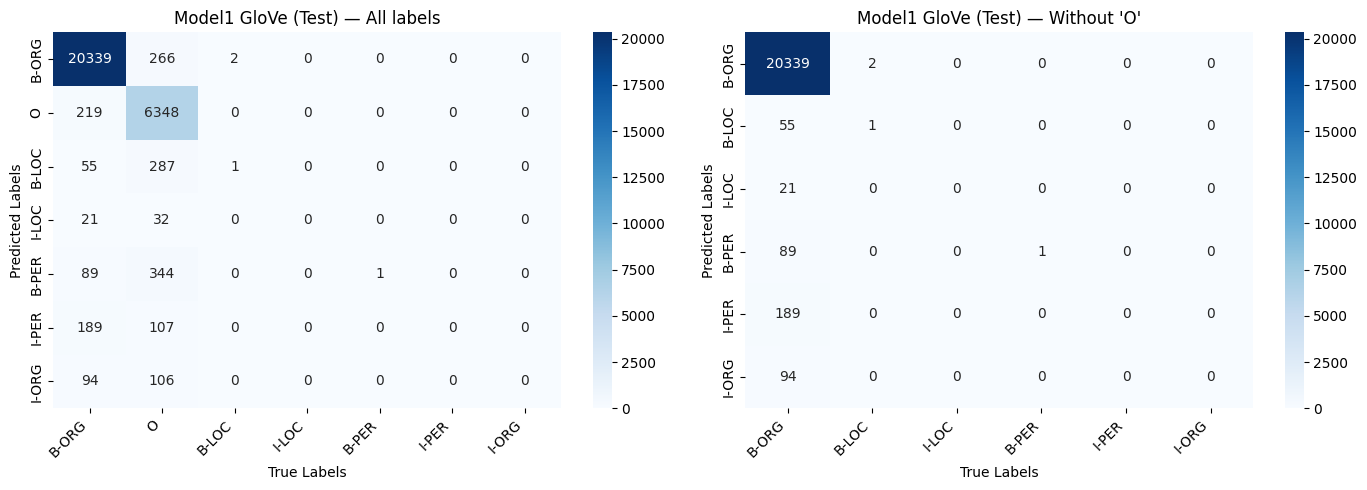


=== Evaluation: Model1 GloVe (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9146 |   0.9365 | 0.9151 |
| Without 'O' |      0.9443 |   0.9274 | 0.9235 |
+-------------+-------------+----------+--------+

[GloVe] Training Model2: hidden=500, layers=2, dirs=1


100%|██████████| 5/5 [00:09<00:00,  1.89s/it]


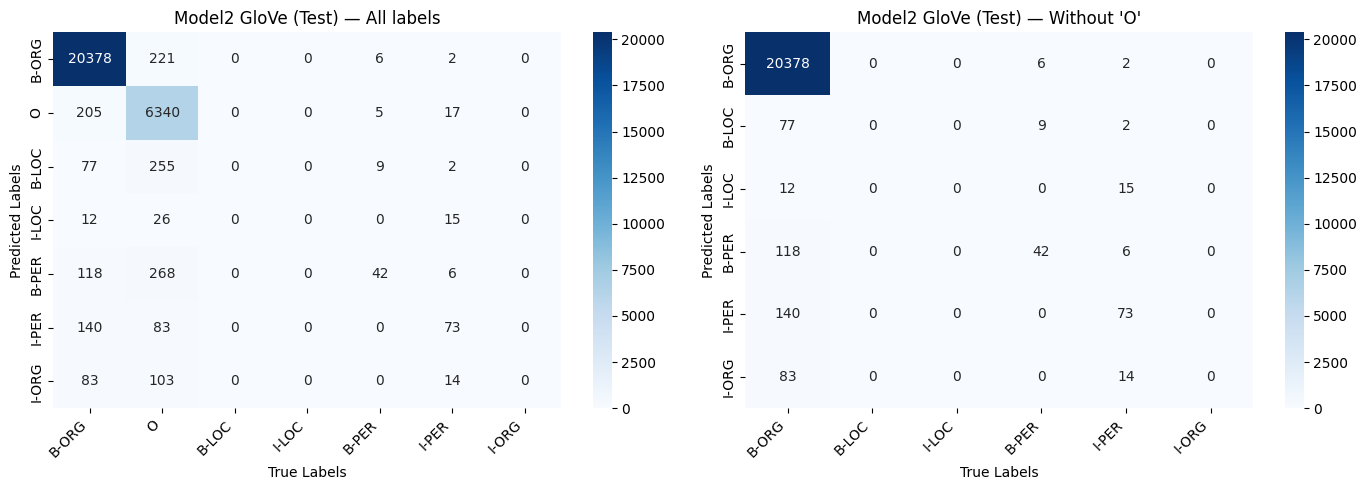


=== Evaluation: Model2 GloVe (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9176 |   0.9415 | 0.9249 |
| Without 'O' |      0.9435 |   0.9343 | 0.9328 |
+-------------+-------------+----------+--------+

[GloVe] Training Model3: hidden=500, layers=3, dirs=1


100%|██████████| 5/5 [00:13<00:00,  2.63s/it]


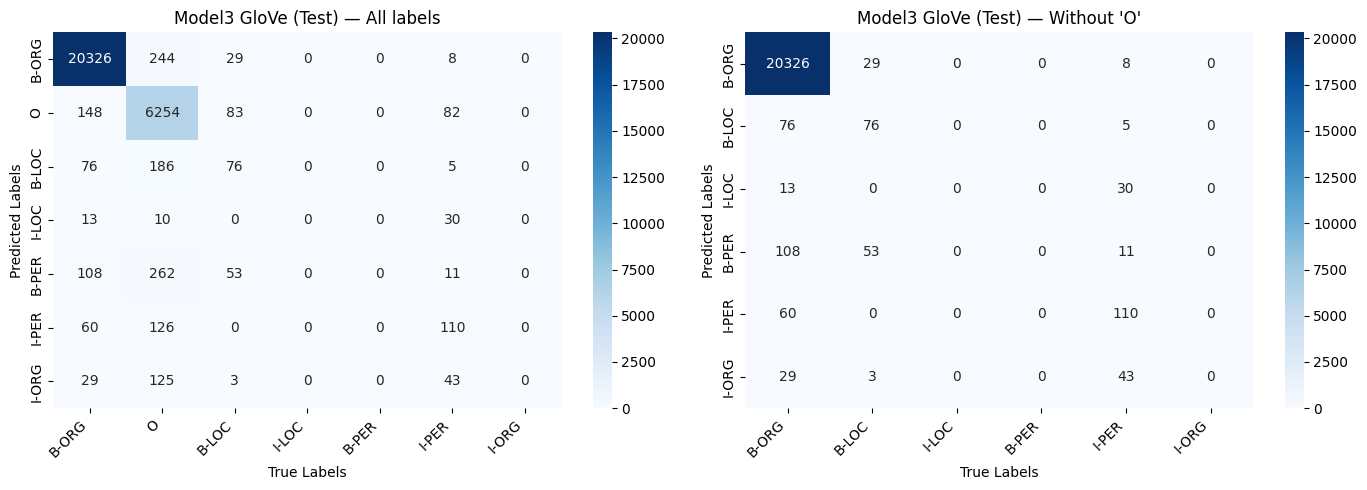


=== Evaluation: Model3 GloVe (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9156 |   0.9392 | 0.9268 |
| Without 'O' |      0.9411 |   0.9352 | 0.9372 |
+-------------+-------------+----------+--------+

[GloVe] Training Model4: hidden=500, layers=1, dirs=2


100%|██████████| 5/5 [00:09<00:00,  1.90s/it]


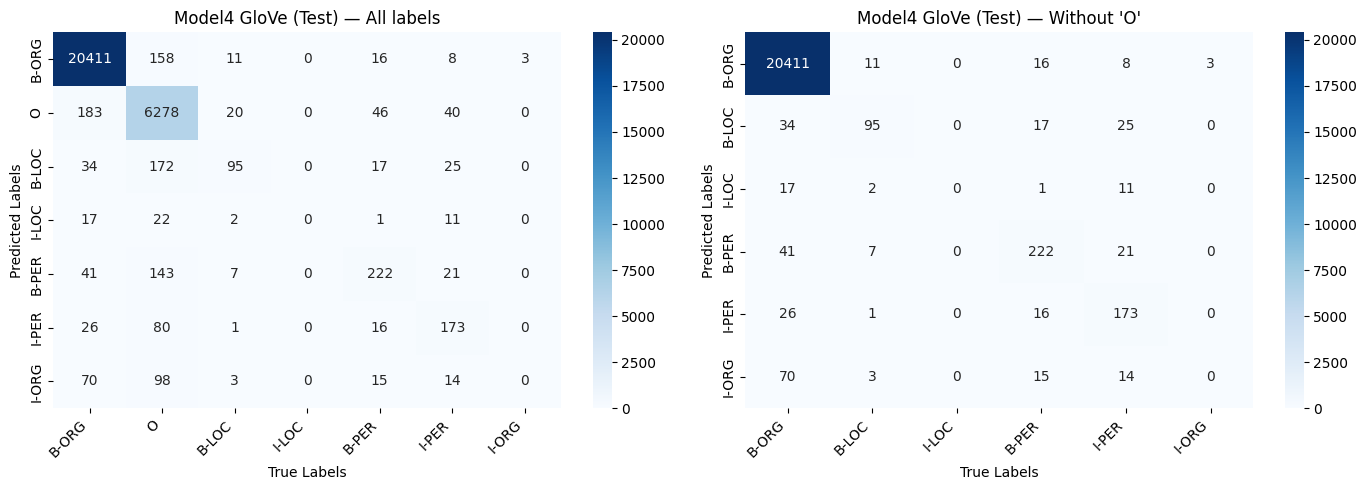


=== Evaluation: Model4 GloVe (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9428 |   0.9536 | 0.9468 |
| Without 'O' |      0.968  |   0.9529 | 0.9579 |
+-------------+-------------+----------+--------+

[GloVe] Training Model5: hidden=500, layers=2, dirs=2


100%|██████████| 5/5 [00:18<00:00,  3.63s/it]


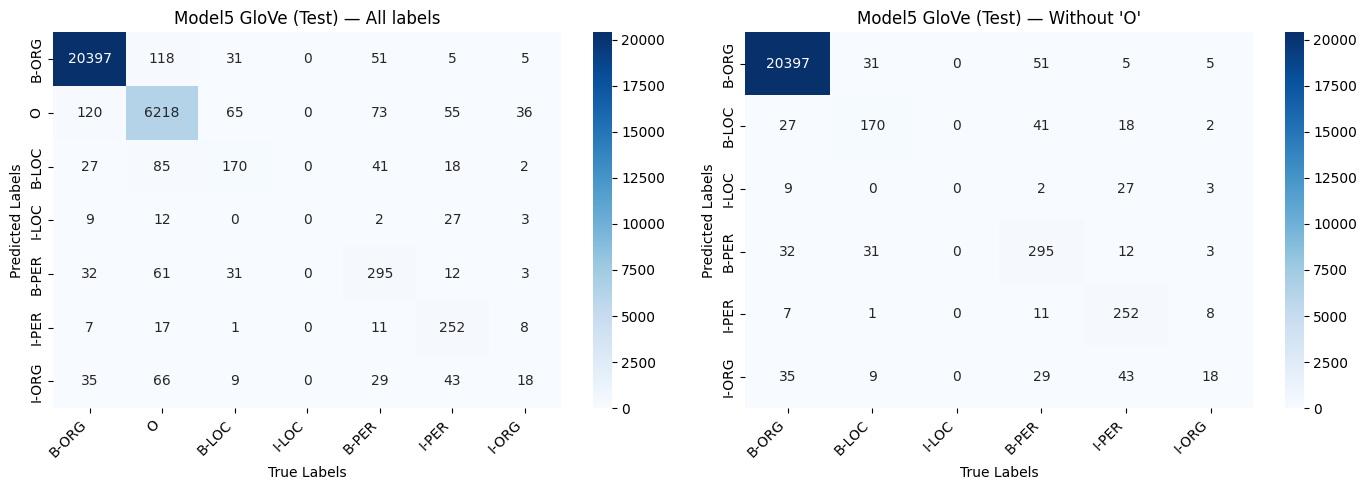


=== Evaluation: Model5 GloVe (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9565 |   0.9596 | 0.9576 |
| Without 'O' |      0.9728 |   0.9635 | 0.9666 |
+-------------+-------------+----------+--------+

[GloVe] Training Model6: hidden=500, layers=3, dirs=2


100%|██████████| 5/5 [00:28<00:00,  5.70s/it]


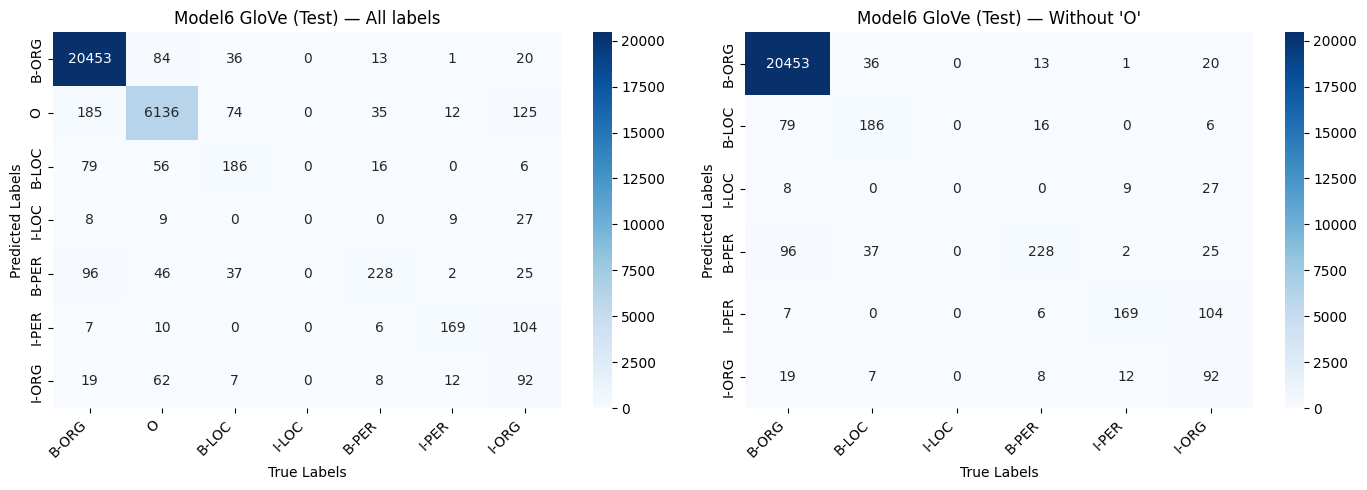


=== Evaluation: Model6 GloVe (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9583 |   0.9566 | 0.9566 |
| Without 'O' |      0.9725 |   0.9633 | 0.9665 |
+-------------+-------------+----------+--------+

[GloVe] Training Model7: hidden=800, layers=1, dirs=2


100%|██████████| 5/5 [00:18<00:00,  3.71s/it]


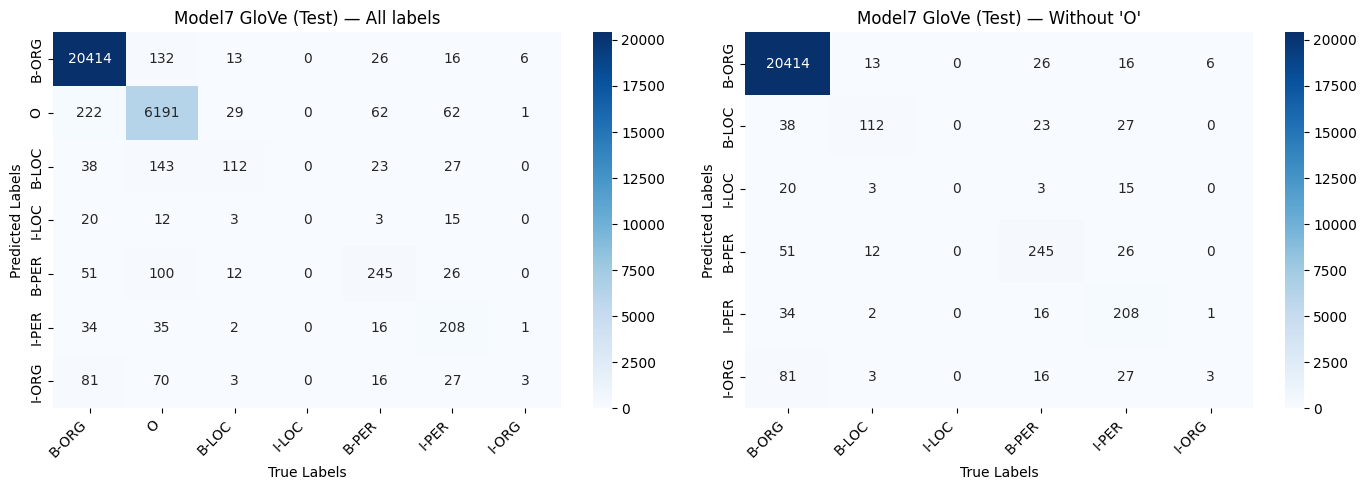


=== Evaluation: Model7 GloVe (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9459 |   0.9534 | 0.9481 |
| Without 'O' |      0.9677 |   0.9566 | 0.9593 |
+-------------+-------------+----------+--------+

[GloVe] Training Model8: hidden=800, layers=2, dirs=2


100%|██████████| 5/5 [00:46<00:00,  9.36s/it]


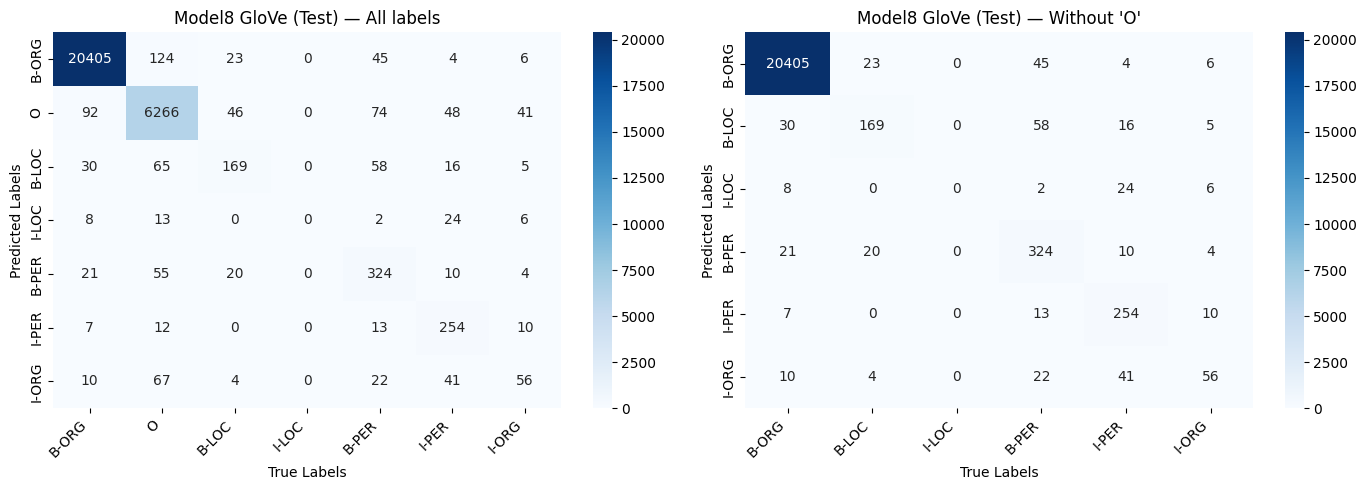


=== Evaluation: Model8 GloVe (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9625 |   0.964  | 0.9627 |
| Without 'O' |      0.9778 |   0.9669 | 0.9711 |
+-------------+-------------+----------+--------+

[GloVe] Training Model9: hidden=800, layers=3, dirs=2


100%|██████████| 5/5 [01:14<00:00, 14.94s/it]


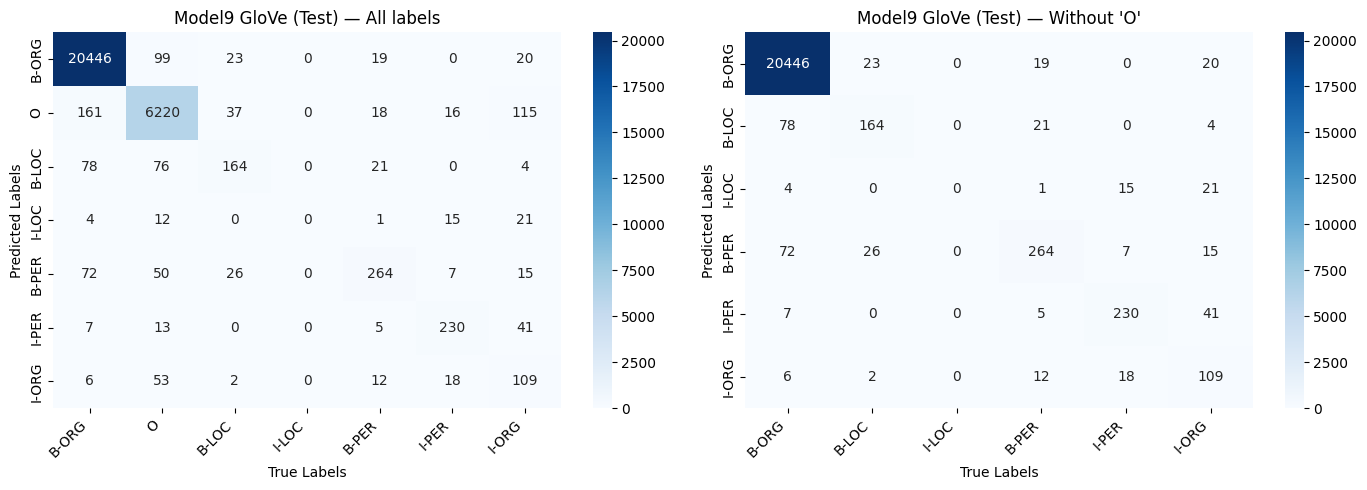


=== Evaluation: Model9 GloVe (Test) ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9617 |   0.9626 | 0.9616 |
| Without 'O' |      0.9763 |   0.9672 | 0.9709 |
+-------------+-------------+----------+--------+

=== GloVe Test Set Results ===
+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |           500 |          1 |            1 |   0.9365 |      0.9146 | 0.9151 |        0.9274 |           0.9443 |    0.9235 |
|  1 | model_2   |           500 |          2 |    

In [38]:
models_glove = {
    "Model1": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 1, "directions": 1},
    "Model2": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 2, "directions": 1},
    "Model3": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 3, "directions": 1},
    "Model4": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 1, "directions": 2},
    "Model5": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 2, "directions": 2},
    "Model6": {"embedding_size": EMB_DIM, "hidden_size": 500, "n_layers": 3, "directions": 2},
    "Model7": {"embedding_size": EMB_DIM, "hidden_size": 800, "n_layers": 1, "directions": 2},
    "Model8": {"embedding_size": EMB_DIM, "hidden_size": 800, "n_layers": 2, "directions": 2},
    "Model9": {"embedding_size": EMB_DIM, "hidden_size": 800, "n_layers": 3, "directions": 2},
}

columns_glove = ["N_MODEL", "HIDDEN_SIZE", "N_LAYERS", "DIRECTIONS",
                 "RECALL", "PRECISION", "F1",
                 "RECALL_WO_O", "PRECISION_WO_O", "F1_WO_O"]
file_name_glove = "NER_results_glove.csv"
res_glove_list  = []

for i, (model_name, params) in enumerate(models_glove.items(), 1):
    print(f"\n{'='*60}")
    print(f"[GloVe] Training {model_name}: hidden={params['hidden_size']}, "
          f"layers={params['n_layers']}, dirs={params['directions']}")
    print("="*60)

    m = NERNet(
        input_size=vocab.n_words,
        embedding_size=params["embedding_size"],
        hidden_size=params["hidden_size"],
        output_size=vocab.n_tags,
        n_layers=params["n_layers"],
        directions=params["directions"],
    )

    # ── Inject GloVe embeddings before training ────────────────────────────
    initialize_from_pretrained_emb(m, emb_matrix)

    train_loop(m, n_epochs=N_EPOCHS,
               dataloader_train=dl_train,
               dataloader_dev=dl_dev)

    er = evaluate(m, title=f"{model_name} GloVe (Test)",
                  dataloader=dl_test, vocab=vocab)

    res_glove_list.append({
        "N_MODEL":        f"model_{i}",
        "HIDDEN_SIZE":    params["hidden_size"],
        "N_LAYERS":       params["n_layers"],
        "DIRECTIONS":     params["directions"],
        "RECALL":         er["recall"],
        "PRECISION":      er["precision"],
        "F1":             er["f1"],
        "RECALL_WO_O":    er["recall_wo_o"],
        "PRECISION_WO_O": er["precision_wo_o"],
        "F1_WO_O":        er["f1_wo_o"],
    })

df_glove = pd.DataFrame(res_glove_list, columns=columns_glove)
df_glove.to_csv(file_name_glove, index=False)
print("\n=== GloVe Test Set Results ===")
print(tabulate(df_glove, headers="keys", tablefmt="psql", floatfmt=".4f"))


## Step 4 - best model
Decide which model performs the best, write its configuration, train it for **10 epochs total** (5 more than the original 5), and evaluate it on the test set.

Training best GloVe model for 10 epochs …


100%|██████████| 10/10 [01:33<00:00,  9.39s/it]



Evaluating best GloVe model on test set …


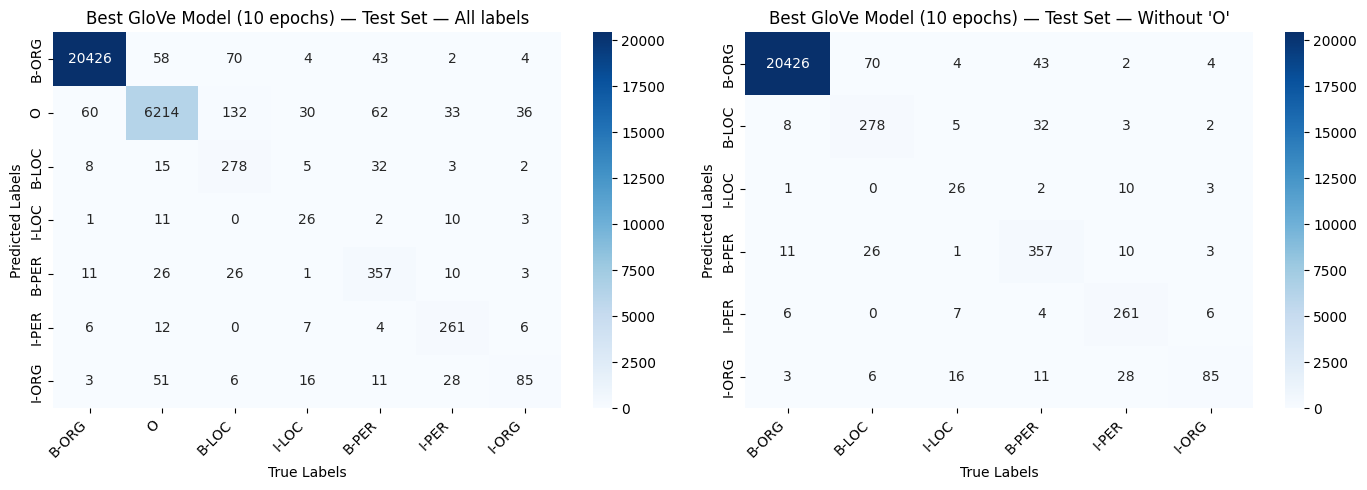


=== Evaluation: Best GloVe Model (10 epochs) — Test Set ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9739 |   0.9701 | 0.9713 |
| Without 'O' |      0.9852 |   0.9772 | 0.9806 |
+-------------+-------------+----------+--------+
+------------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
| N_MODEL    |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|------------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
| Best GloVe |           800 |          2 |            2 |   0.9701 |      0.9739 | 0.9713 |        0.9772 |           0.9852 |    0.9806 |
+------------+---------------+------------+--------------+----------+----------

In [39]:
best_model_glove_cfg = {"embedding_size": EMB_DIM,
                        "hidden_size": 800,
                        "n_layers": 2,
                        "directions": 2}

best_glove_model = NERNet(
    input_size=vocab.n_words,
    embedding_size=best_model_glove_cfg["embedding_size"],
    hidden_size=best_model_glove_cfg["hidden_size"],
    output_size=vocab.n_tags,
    n_layers=best_model_glove_cfg["n_layers"],
    directions=best_model_glove_cfg["directions"],
)

# Inject GloVe embeddings
initialize_from_pretrained_emb(best_glove_model, emb_matrix)

print("Training best GloVe model for 10 epochs …")
_ = train_loop(best_glove_model, n_epochs=10,
               dataloader_train=dl_train,
               dataloader_dev=dl_dev)

print("\nEvaluating best GloVe model on test set …")
best_glove_results = evaluate(best_glove_model,
                              title="Best GloVe Model (10 epochs) — Test Set",
                              dataloader=dl_test,
                              vocab=vocab)

print(tabulate(
    [["Best GloVe", best_model_glove_cfg["hidden_size"],
      best_model_glove_cfg["n_layers"], best_model_glove_cfg["directions"],
      best_glove_results["recall"], best_glove_results["precision"],
      best_glove_results["f1"],
      best_glove_results["recall_wo_o"], best_glove_results["precision_wo_o"],
      best_glove_results["f1_wo_o"]]],
    headers=["N_MODEL","HIDDEN_SIZE","N_LAYERS","DIRECTIONS",
             "RECALL","PRECISION","F1",
             "RECALL_WO_O","PRECISION_WO_O","F1_WO_O"],
    tablefmt="psql", floatfmt=".4f"
))


# Part 5 - Error Analysis

In this part, you'll analyze the errors made by your best model to understand its strengths and weaknesses.

## Step 1: Extract Predictions

First, let's extract predictions from your best model on the test set:

In [40]:
def get_predictions(model, dataloader, vocab, PAD_TOKEN, DEVICE):
    """
    Get predictions from the model on a dataloader.

    Returns:
        - true_tags_list: List of lists of true tag strings
        - pred_tags_list: List of lists of predicted tag strings
        - words_list: List of lists of words
    """
    import torch

    model.eval()
    true_tags_list = []
    pred_tags_list = []
    words_list = []

    with torch.no_grad():
        for batch in dataloader:
            # Dataloader yields (input_ids, labels) pairs.
            input_ids, labels = batch
            input_ids = input_ids.to(DEVICE)
            labels = labels.to(DEVICE)

            # Get model predictions.
            outputs = model(input_ids)
            _, predicted = torch.max(outputs, 2)

            # Process each sequence in the batch.
            for i in range(input_ids.size(0)):
                # Get sequence length (ignoring padding).
                seq_len = (input_ids[i] != PAD_TOKEN).sum().item()

                # Convert ids back to tag strings and words.
                true_tags = [vocab.id2tag[tag.item()] for tag in labels[i][:seq_len]]
                pred_tags = [vocab.id2tag[tag.item()] for tag in predicted[i][:seq_len]]
                words = [vocab.id2word[word.item()] for word in input_ids[i][:seq_len]]

                true_tags_list.append(true_tags)
                pred_tags_list.append(pred_tags)
                words_list.append(words)

    return true_tags_list, pred_tags_list, words_list

## Step 2: Helper Functions

Before writing the error analysis, implement two utility functions that you will need.

### 2a: `get_entities_simple(tags)`

**Goal:** Extract named entities from a single IOB tag sequence.

**Input:** A list of IOB tag strings, e.g. `['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'O']`

**Output:** A list of tuples `(start_idx, end_idx, entity_type)` where:
- `start_idx` is the index of the `B-` tag
- `end_idx` is the index of the last `I-` tag of that entity (or same as `start_idx` if the entity is a single token)
- `entity_type` is the string after `B-`/`I-` (e.g. `"PER"`, `"LOC"`, `"ORG"`)

**Logic:** Walk through the tag list. When you see a `B-X` tag, start a new entity. Keep extending it while the next tags are `I-X` (same type). When the entity ends, append the tuple. Ignore `O` tags.

**Example:**
```python
tags = ['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'O']
get_entities_simple(tags)
# Returns: [(1, 2, 'PER'), (4, 4, 'LOC')]
```

### 2b: `has_overlap(start1, end1, start2, end2)`

**Goal:** Check if two index spans share at least one position.

**Input:** Four integers — start and end indices of two spans.

**Output:** `True` if they overlap, `False` otherwise.

**Example:**
```python
has_overlap(1, 3, 2, 5)  # True  (overlap at indices 2, 3)
has_overlap(1, 2, 4, 5)  # False (no shared indices)
```

In [42]:
def get_entities_simple(tags):
    """
    Extract entities from a sequence of IOB tags.

    Args:
        tags: List of tag strings, e.g. ['O', 'B-PER', 'I-PER', 'O']

    Returns:
        List of (start_idx, end_idx, entity_type) tuples.
        Example: [(1, 2, 'PER')]
    """
    entities = []
    current_start = None
    current_type  = None

    for i, tag in enumerate(tags):
        if tag.startswith("B-"):
            # Close any open entity first
            if current_start is not None:
                entities.append((current_start, i - 1, current_type))
            # Start a new entity
            current_start = i
            current_type  = tag[2:]   # strip "B-"
        elif tag.startswith("I-"):
            etype = tag[2:]
            if current_start is None or etype != current_type:
                # Malformed: I- without matching B- (treat as new entity start)
                if current_start is not None:
                    entities.append((current_start, i - 1, current_type))
                current_start = i
                current_type  = etype
            # else: continuation do nothing, end index will be updated at close
        else:
            # "O" or any other non-entity tag: close open entity
            if current_start is not None:
                entities.append((current_start, i - 1, current_type))
                current_start = None
                current_type  = None

    # Close entity that runs to the end of the sequence
    if current_start is not None:
        entities.append((current_start, len(tags) - 1, current_type))

    return entities


def has_overlap(start1, end1, start2, end2):
    """
    Check if two spans overlap (share at least one index).

    Args:
        start1, end1: inclusive start/end indices of the first span
        start2, end2: inclusive start/end indices of the second span

    Returns:
        True if the spans overlap, False otherwise.
    """
    # Two spans overlap iff neither ends before the other starts
    return start1 <= end2 and start2 <= end1


# ── Quick unit tests ──────────────────────────────────────────────────────────
assert get_entities_simple(['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'O']) == [(1, 2, 'PER'), (4, 4, 'LOC')]
assert has_overlap(1, 3, 2, 5) is True
assert has_overlap(1, 2, 4, 5) is False
print("Helper function works ")


Helper function works 


## Step 3: Implement Entity-Level Error Analysis

**Goal:** Compare the true and predicted entity spans (extracted using `get_entities_simple`) to count and categorize errors at the **entity level**.

**Function signature:**
```python
def simple_analyze_errors(true_tags, pred_tags, words) -> dict
```

**Inputs:**
- `true_tags`: list of lists of tag strings (one inner list per sentence)
- `pred_tags`: list of lists of tag strings (one inner list per sentence)
- `words`: list of lists of word strings (one inner list per sentence)

**What to do — for each sentence:**
1. Extract true entities using `get_entities_simple(true_tags[i])`
2. Extract predicted entities using `get_entities_simple(pred_tags[i])`
3. Classify each **true entity** into one of these categories:
   - **Correct:** A predicted entity has the exact same `(start, end, type)`.
   - **Type error:** A predicted entity has the same `(start, end)` but a **different** type (e.g., true=`PER`, predicted=`ORG`).
   - **Boundary error:** A predicted entity **overlaps** (use `has_overlap`) and has the **same type**, but the start/end indices differ.
   - **Missed:** No predicted entity overlaps with this true entity at all.
4. Also count **Spurious** predictions: predicted entities that do **not** overlap with any true entity.

**Return value — a dictionary:**
```python
{
    'total_entities': int,       # total number of true entities across all sentences
    'correct_entities': int,     # number of exact matches
    'accuracy': float,           # correct_entities / total_entities
    'error_counts': {
        'type_error': int,
        'boundary_error': int,
        'missed': int,
        'spurious': int
    },
    'error_examples': {          # store up to 3 examples per category
        'type_error': [(words, true_entity, pred_entity), ...],
        'boundary_error': [(words, true_entity, pred_entity), ...],
        'missed': [(words, true_entity), ...],
        'spurious': [(words, pred_entity), ...]
    }
}
```

**Example walkthrough:**
```python
true_tags = [['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'I-LOC', 'O']]
pred_tags = [['O', 'B-PER', 'O',     'O', 'B-ORG', 'I-ORG', 'O']]
words     = [['The', 'John', 'Smith', 'visited', 'New', 'York', 'yesterday']]

# True entities:  [(1,2,'PER'), (4,5,'LOC')]
# Pred entities:  [(1,1,'PER'), (4,5,'ORG')]
#
# (1,2,'PER') vs (1,1,'PER') → boundary_error (same type PER, overlapping spans, but end differs)
# (4,5,'LOC') vs (4,5,'ORG') → type_error (same span, different type)
```

In [43]:
def simple_analyze_errors(true_tags, pred_tags, words):
    """
    Analyze errors in NER predictions at the entity level.

    Args:
        true_tags: List of lists of true tag strings  (one list per sentence)
        pred_tags: List of lists of predicted tag strings (one per sentence)
        words:     List of lists of word strings          (one per sentence)

    Returns:
        dict with keys: total_entities, correct_entities, accuracy,
                        error_counts (dict), error_examples (dict)
    """
    # ── Initialise counters ────────────────────────────────────────────────
    total_entities   = 0
    correct_entities = 0
    error_counts = {"type_error": 0, "boundary_error": 0,
                    "missed": 0, "spurious": 0}
    error_examples = {"type_error":    [],   # (words, true_ent, pred_ent)
                      "boundary_error": [],
                      "missed":        [],   # (words, true_ent)
                      "spurious":      []}   # (words, pred_ent)

    MAX_EXAMPLES = 3   # store at most this many examples per category

    for sent_words, sent_true, sent_pred in zip(words, true_tags, pred_tags):
        true_ents = get_entities_simple(sent_true)
        pred_ents = get_entities_simple(sent_pred)

        # Track which predicted entities have been matched (for spurious check)
        matched_preds = set()

        # ── Classify each TRUE entity ──────────────────────────────────────
        for te in true_ents:
            t_start, t_end, t_type = te
            total_entities += 1

            matched_to_exact  = False
            matched_to_type   = False
            matched_to_boundary = False

            for pi, pe in enumerate(pred_ents):
                p_start, p_end, p_type = pe

                exact_match = (p_start == t_start and p_end == t_end
                               and p_type == t_type)
                same_span   = (p_start == t_start and p_end == t_end)
                same_type   = (p_type == t_type)
                overlap     = has_overlap(t_start, t_end, p_start, p_end)

                if exact_match:
                    matched_to_exact = True
                    matched_preds.add(pi)
                    break
                elif same_span and not same_type:
                    matched_to_type = True
                    if len(error_examples["type_error"]) < MAX_EXAMPLES:
                        error_examples["type_error"].append(
                            (sent_words, te, pe))
                    matched_preds.add(pi)
                elif overlap and same_type and not same_span:
                    matched_to_boundary = True
                    if len(error_examples["boundary_error"]) < MAX_EXAMPLES:
                        error_examples["boundary_error"].append(
                            (sent_words, te, pe))
                    matched_preds.add(pi)

            if matched_to_exact:
                correct_entities += 1
            elif matched_to_type:
                error_counts["type_error"] += 1
            elif matched_to_boundary:
                error_counts["boundary_error"] += 1
            else:
                # No predicted entity overlaps with this true entity
                error_counts["missed"] += 1
                if len(error_examples["missed"]) < MAX_EXAMPLES:
                    error_examples["missed"].append((sent_words, te))

        # ── Count spurious predicted entities ─────────────────────────────
        for pi, pe in enumerate(pred_ents):
            if pi in matched_preds:
                continue
            # Check whether this predicted entity overlaps ANY true entity
            is_spurious = not any(
                has_overlap(pe[0], pe[1], te[0], te[1])
                for te in true_ents
            )
            if is_spurious:
                error_counts["spurious"] += 1
                if len(error_examples["spurious"]) < MAX_EXAMPLES:
                    error_examples["spurious"].append((sent_words, pe))

    accuracy = correct_entities / total_entities if total_entities > 0 else 0.0

    return {
        "total_entities":   total_entities,
        "correct_entities": correct_entities,
        "accuracy":         accuracy,
        "error_counts":     error_counts,
        "error_examples":   error_examples,
    }


## Step 4: Display the Error Analysis

**Goal:** Print a readable summary of the error analysis dictionary returned by `simple_analyze_errors`.

**Function signature:**
```python
def print_error_analysis(analysis):
```

**Input:** The dictionary returned by `simple_analyze_errors`.

**What to print — three sections:**

**Section 1 — Overall statistics** (use `tabulate` or simple print statements):
```
Total entities:     500
Correct:            420 (84.0%)
Type errors:         15
Boundary errors:     25
Missed:              40
Spurious:            30
```

**Section 2 — Examples for each error type.** Print up to 3 examples per category, showing the sentence words and the relevant entity span. Format each example like:
```
[Type Error] "... New York ..." — true: LOC(4,5), predicted: ORG(4,5)
[Missed]     "... John Smith ..." — true: PER(1,2), predicted: (none)
```

**Section 3 — Which entity type (PER / LOC / ORG) has the most errors?** Print one line stating the answer.

In [44]:
def print_error_analysis(analysis):
    """
    Print a readable summary of the error analysis results.

    Args:
        analysis: Dictionary returned by simple_analyze_errors
    """
    total   = analysis["total_entities"]
    correct = analysis["correct_entities"]
    acc     = analysis["accuracy"]
    ec      = analysis["error_counts"]
    ee      = analysis["error_examples"]

    # ── Section 1: Overall statistics ────────────────────────────────────────
    print("=" * 60)
    print("ENTITY-LEVEL ERROR ANALYSIS")
    print("=" * 60)
    stats = [
        ["Total entities",   total,             ""],
        ["Correct",          correct,           f"({100*acc:.1f}%)"],
        ["Type errors",      ec["type_error"],  ""],
        ["Boundary errors",  ec["boundary_error"], ""],
        ["Missed",           ec["missed"],      ""],
        ["Spurious",         ec["spurious"],    ""],
    ]
    print(tabulate(stats, tablefmt="simple"))

    # ── Section 2: Examples per error category ────────────────────────────────
    print("\n" + "=" * 60)
    print("ERROR EXAMPLES")
    print("=" * 60)

    def _fmt_span(sent_words, start, end):
        """Return a short context string around the entity span."""
        ctx_start = max(0, start - 2)
        ctx_end   = min(len(sent_words), end + 3)
        snippet   = " ".join(sent_words[ctx_start:ctx_end])
        return f'"{snippet}"'

    # Type errors
    print("\n[Type Errors]")
    if ee["type_error"]:
        for sent_words, te, pe in ee["type_error"]:
            ctx = _fmt_span(sent_words, te[0], te[1])
            print(f"  {ctx} — true: {te[2]}({te[0]},{te[1]}), "
                  f"predicted: {pe[2]}({pe[0]},{pe[1]})")
    else:
        print("  (none)")

    # Boundary errors
    print("\n[Boundary Errors]")
    if ee["boundary_error"]:
        for sent_words, te, pe in ee["boundary_error"]:
            ctx = _fmt_span(sent_words, te[0], te[1])
            print(f"  {ctx} — true: {te[2]}({te[0]},{te[1]}), "
                  f"predicted: {pe[2]}({pe[0]},{pe[1]})")
    else:
        print("  (none)")

    # Missed entities
    print("\n[Missed Entities]")
    if ee["missed"]:
        for sent_words, te in ee["missed"]:
            ctx = _fmt_span(sent_words, te[0], te[1])
            print(f"  {ctx} — true: {te[2]}({te[0]},{te[1]}), predicted: (none)")
    else:
        print("  (none)")

    # Spurious predictions
    print("\n[Spurious Predictions]")
    if ee["spurious"]:
        for sent_words, pe in ee["spurious"]:
            ctx = _fmt_span(sent_words, pe[0], pe[1])
            print(f"  {ctx} — spurious prediction: {pe[2]}({pe[0]},{pe[1]})")
    else:
        print("  (none)")

    # ── Section 3: Which entity type has the most errors ─────────────────────
    print("\n" + "=" * 60)
    print("ERROR DISTRIBUTION BY ENTITY TYPE")
    print("=" * 60)

    type_errors = defaultdict(int)

    def _tally(examples, has_pred=True):
        for item in examples:
            if has_pred:
                sent_words, te, pe = item
                type_errors[te[2]] += 1
            else:
                # spurious: count the predicted type
                sent_words, pe = item
                type_errors[pe[2]] += 1

    _tally(ee["type_error"],    has_pred=True)
    _tally(ee["boundary_error"], has_pred=True)
    # For missed entities the true entity was not found
    for sent_words, te in ee["missed"]:
        type_errors[te[2]] += 1
    # For spurious: blame the predicted type
    _tally(ee["spurious"], has_pred=False)

    if type_errors:
        worst_type = max(type_errors, key=type_errors.get)
        for t, n in sorted(type_errors.items(), key=lambda x: -x[1]):
            print(f"  {t:6s}: {n} errors")
        print(f"\n→ Entity type with the MOST errors: {worst_type} "
              f"({type_errors[worst_type]} errors in examples shown)")
    else:
        print("  No errors recorded in examples.")


## Step 5: Improvement Suggestions

**Goal:** Based on the output of your error analysis, write **3 concrete improvement suggestions** below (no code required — just text).

**Requirements:**
- Write 2–4 sentences per suggestion.
- Each suggestion **must reference a specific finding** from your error analysis (e.g., "42% of errors are boundary errors on PER entities, which suggests...").
- Choose 3 of the following directions:
  1. Using a **CRF layer** on top of the LSTM to enforce valid IOB transitions
  2. Using **subword or character-level embeddings** to handle rare / OOV entity words
  3. Adding more **training data or data augmentation** for the weakest entity type
  4. Using **contextual embeddings** (e.g., BERT) instead of static word embeddings
  5. **Post-processing rules** to fix common boundary errors

**Expected output:** A markdown cell (below) with three numbered paragraphs.

In [45]:
# First, extract predictions from your best model on the test set
true_tags_list, pred_tags_list, words_list = get_predictions(model, dl_test, vocab, PAD_TOKEN, DEVICE)

# Run the error analysis
analysis = simple_analyze_errors(true_tags_list, pred_tags_list, words_list)

# Display the results
print_error_analysis(analysis)

ENTITY-LEVEL ERROR ANALYSIS
---------------  ----  -------
Total entities   1127
Correct           217  (19.3%)
Type errors        57
Boundary errors    50
Missed            803
Spurious          101
---------------  ----  -------

ERROR EXAMPLES

[Type Errors]
  "__unk__ , __unk__ 1996-08-21" — true: LOC(2,2), predicted: PER(2,2)
  "Lauck 's lawyer" — true: PER(0,0), predicted: ORG(0,0)
  "1 ( __unk__ __unk__ )" — true: PER(3,3), predicted: LOC(3,3)

[Boundary Errors]
  "326 ( D. Cox 95 not" — true: PER(6,7), predicted: PER(7,7)
  "Novotna ( Czech Republic ) __unk__" — true: LOC(14,15), predicted: LOC(14,14)
  "Campbell ( New Zealand ) ," — true: LOC(8,9), predicted: LOC(8,8)

[Missed Entities]
  "__unk__ __unk__ is also" — true: PER(0,1), predicted: (none)
  "MILWAUKEE 61 68" — true: ORG(0,0), predicted: (none)
  "__unk__ , __unk__" — true: LOC(0,0), predicted: (none)

[Spurious Predictions]
  ") beat 5 - __unk__" — spurious prediction: PER(8,8)
  "RTRS - Golf : Norman" — spurious pr

### Your Improvement Suggestions

*(Write your 3 suggestions here)*

1. **Sub-Word Tokenization or Character Embeddings**

Implementing sub-word tokenization or a character-level encoder directly captures word structure and prefixes/suffixes, which prevents out-of-vocabulary terms from becoming anonymous __unk__ placeholders. This provides better feature signals that allow the model to recognize hidden or unseen entities, directly resolving the 803 completely missed entity errors.

2. **Integrating a Conditional Random Field (CRF) Layer**

Adding a CRF layer on top of the LSTM outputs models global sequence transition probabilities, which mathematically penalizes structural anomalies like an I- tag incorrectly trailing an O tag. This forces the network to maintain strict label cohesion across multi-word entities, preventing the truncation issues seen in your boundary errors (e.g., extracting only "Czech" out of "Czech Republic").

3. **Appending a Casing and Capitalization Feature Vector**

Explicitly concatenating a parallel, categorical case-structure vector (tracking traits like is_all_caps or is_capitalized) to the word embeddings provides a robust, hand-crafted feature for proper nouns in English text. This additional context directly corrects type errors and spurious predictions by preventing the model from hallucinating entity tags on lowercase context words or misclassifying sports-header capitalization lists.

# Testing

Before running the tests:
1. Create a **sharing link** to your notebook with **editor access**.
2. Paste it in the `NOTEBOOK_LINK` variable below.

Then run the test cells to create the `results.json` file.

In [78]:
glove_root_path = 'glove.6B.300d.txt'
glove_sub_path = 'data/glove/glove.6B.300d.txt'
glove_zip = 'glove.6B.zip'
glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"

if not os.path.exists(glove_root_path):
    print("GloVe not found in root. Searching...")

    if os.path.exists(glove_sub_path):
        print("Found GloVe in 'data/glove/'. Copying to root directory...")
        shutil.copy(glove_sub_path, glove_root_path)
    else:
        print("GloVe is completely missing from the workspace. Re-downloading (≈822 MB)...")
        urllib.request.urlretrieve(glove_url, glove_zip)
        print("Extracting only the 300d vector file...")
        with zipfile.ZipFile(glove_zip) as zf:
            zf.extract(glove_root_path, ".")
        os.remove(glove_zip) # Clean up zip to save RAM

    print("✅ GloVe file is now successfully locked in the root directory!")
else:
    print("✅ GloVe file is already in the root directory. Ready to test!")

GloVe not found in root. Searching...
GloVe is completely missing from the workspace. Re-downloading (≈822 MB)...
Extracting only the 300d vector file...
✅ GloVe file is now successfully locked in the root directory!


In [79]:
NOTEBOOK_LINK = "https://colab.research.google.com/drive/1rqQ9ta_D7i-uSQ4FtiNIGD3FrhWpexku?usp=sharing"

100%|██████████| 10/10 [02:30<00:00, 15.05s/it]


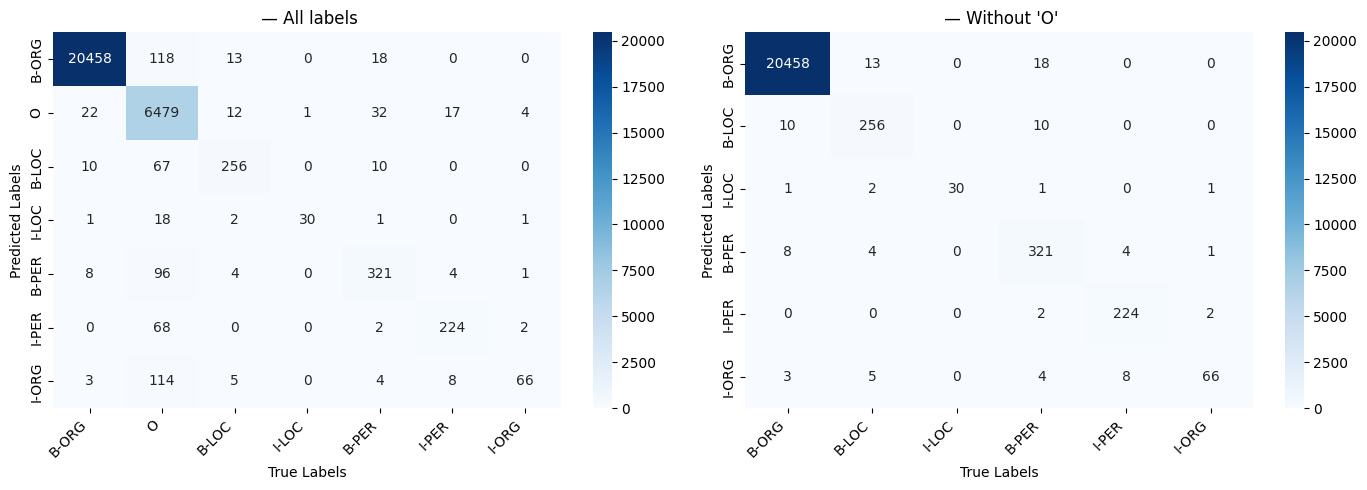


=== Evaluation:  ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9764 |   0.9766 | 0.9752 |
| Without 'O' |      0.9945 |   0.9736 | 0.9821 |
+-------------+-------------+----------+--------+


100%|██████████| 10/10 [01:33<00:00,  9.39s/it]


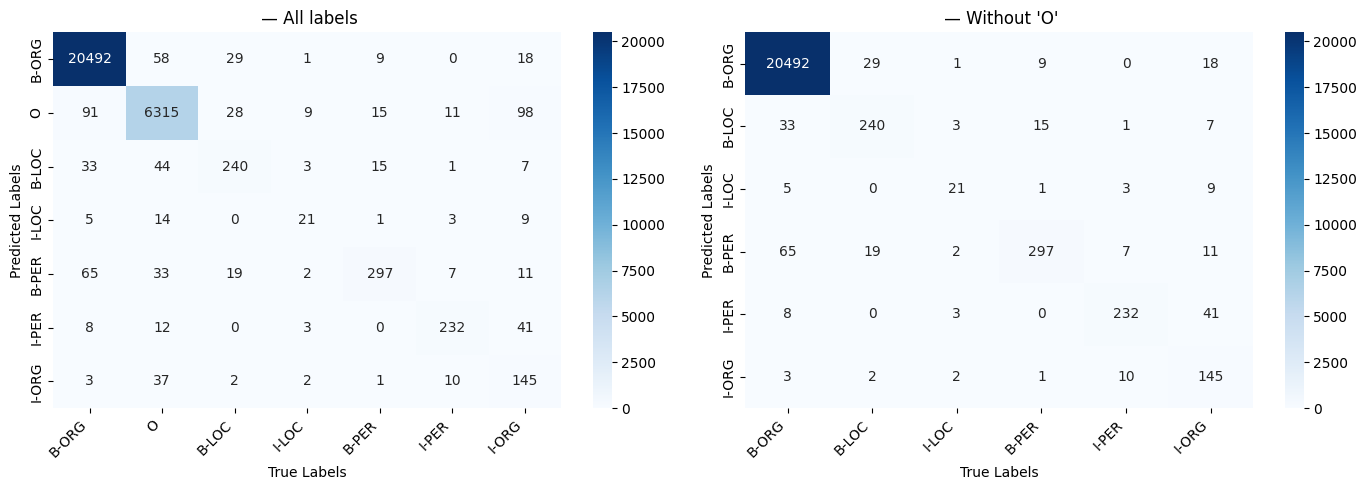


=== Evaluation:  ===
+-------------+-------------+----------+--------+
|             |   Precision |   Recall |     F1 |
|-------------+-------------+----------+--------|
| All labels  |      0.9749 |   0.9734 | 0.9737 |
| Without 'O' |      0.9852 |   0.9769 | 0.9804 |
+-------------+-------------+----------+--------+


In [80]:
########################################
# Tests

import json

def test_link():
    return {
        'link': NOTEBOOK_LINK
    }

train_ds = read_data("data/train.txt")
dev_ds = read_data("data/dev.txt")
test_ds = read_data("data/test.txt")
def test_read_data():
    result = {
        'lengths': (len(train_ds), len(dev_ds), len(test_ds)),
    }
    return result

vocab = Vocab(train_ds)
def test_vocab():
    sent = vocab.index_words(["I", "am", "Spongebob"])
    return {
        'length': vocab.n_words,
        'tag2id_length': len(vocab.tag2id),
        "Spongebob": sent[2]
    }

train_sequences = prepare_data(train_ds, vocab)
dev_sequences = prepare_data(dev_ds, vocab)
test_sequences = prepare_data(test_ds, vocab)

def test_count_oov():
    return {
        'dev_oov': count_oov(dev_sequences),
        'test_oov': count_oov(test_sequences)
    }

BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)

def test_prepare_data_loader():
    return {
        'lengths': (len(dl_train), len(dl_dev), len(dl_test))
    }


def test_NERNet():
    # Extract best model configuration
    hidden_size = best_model_cfg['hidden_size']
    n_layers = best_model_cfg['n_layers']
    directions = best_model_cfg['directions']


    # Create model
    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=hidden_size, output_size=vocab.n_tags, n_layers=n_layers, directions=directions)
    best_model.to(DEVICE)

    # Train model and evaluate
    _ = train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)

    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

def test_glove():
    # Get embeddings
    emb_file = 'glove.6B.300d.txt'
    emb_matrix = get_emb_matrix(emb_file, vocab)

    # Extract best model configuration
    hidden_size = best_model_glove_cfg['hidden_size']
    n_layers = best_model_glove_cfg['n_layers']
    directions = best_model_glove_cfg['directions']

    # Create model
    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=hidden_size, output_size=vocab.n_tags, n_layers=n_layers, directions=directions)
    best_model.to(DEVICE)
    initialize_from_pretrained_emb(best_model, emb_matrix)

    # Train model and evaluate
    _ = train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)

    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

TESTS = [
    test_link,
    test_read_data,
    test_vocab,
    test_count_oov,
    test_prepare_data_loader,
    test_NERNet,
    test_glove
]

# Run tests and save results
res = {}
for test in TESTS:
    try:
        cur_res = test()
        res.update({test.__name__: cur_res})
    except Exception as e:
        import traceback
        res.update({test.__name__: repr(e) + "\n" + traceback.format_exc()})

with open('results.json', 'w') as f:
    json.dump(res, f, indent=2)

########################################

---

# 📤 Submit Your Assignment to GitHub

## Step 1: Authentication Setup (One-Time)

Before you can submit, you need to set up GitHub authentication.

### Creating a GitHub Personal Access Token:

1. **Go to GitHub Token Settings**: [https://github.com/settings/tokens](https://github.com/settings/tokens)

2. **Click "Generate new token (classic)"**

3. **Configure your token**:
   - **Note**: "NLP Course Assignments" (or any name you like)
   - **Expiration**: 90 days (or custom)
   - **Select scopes**: Check **`repo`** (full control of private repositories)

4. **Click "Generate token"**

5. **IMPORTANT**: Copy the token immediately and save it somewhere safe!
   - Like Colab Secrets (see picture)
   - You won't be able to see it again
   - You can reuse this token for all assignments
   - Don't share it with anyone

### Run the authentication cell below

You only need to do this **once per Colab session**. If you restart the runtime, you'll need to re-run the authentication cell.

---

In [65]:
"""
GitHub Authentication Setup
Run this cell ONCE to set up your GitHub credentials
"""

import os
from getpass import getpass

def setup_github_auth():
    """Set up GitHub credentials - run once per Colab session"""
    global GITHUB_USERNAME, GITHUB_TOKEN

    print("🔐 GitHub Authentication Setup")
    print("=" * 60)

    GITHUB_USERNAME = input("GitHub username: ")
    GITHUB_TOKEN = getpass("GitHub Personal Access Token (hidden): ")

    print("\n✅ Credentials saved for this session!")
    print("You can now run the submission cell below.")
    print("\n💡 Tip: Your credentials are only stored in this runtime.")
    print("If you restart the runtime, you'll need to run this cell again.")

# Run the setup
setup_github_auth()

🔐 GitHub Authentication Setup
GitHub username: yossefpartouche
GitHub Personal Access Token (hidden): ··········

✅ Credentials saved for this session!
You can now run the submission cell below.

💡 Tip: Your credentials are only stored in this runtime.
If you restart the runtime, you'll need to run this cell again.


---

## Step 2: Submit Your Results

Once you've:
- ✅ Completed all the code cells above
- ✅ Run all the test cells
- ✅ Generated `results.json`
- ✅ Run the authentication cell

You can now submit your assignment by running the cell below!

### What you'll need:
- Your **GitHub Classroom repository URL**
  - You received this when you accepted the assignment
  - Format: `https://github.com/NLP-Reichman/2026-assignment-2-team-name`
- (Optional) A custom commit message

### After submission:
- Check your repository to see `results.json` has been uploaded
- Visit the **Actions** tab to see your autograding results
- Results typically appear within 1-2 minutes

---

In [81]:
"""
Submit Assignment to GitHub
Run this cell to push your results.json to GitHub
"""

import os
import subprocess
import json

def check_credentials():
    """Check if credentials are set"""
    try:
        _ = GITHUB_USERNAME
        _ = GITHUB_TOKEN
        return True
    except NameError:
        print("\u274c GitHub credentials not found!")
        print("Please run the authentication cell above first.")
        return False


def check_results_file():
    """Check if results.json exists"""
    if not os.path.exists('results.json'):
        print("\u274c results.json not found!")
        print("\nPlease run all the test cells above to generate results.json")
        return False

    # Display test summary
    try:
        with open('results.json', 'r') as f:
            results = json.load(f)

        print("\U0001f4ca Test Results Found:")
        print("-" * 60)
        for test_name in results.keys():
            print(f"  \u2713 {test_name}")
        print("-" * 60)
        return True
    except Exception as e:
        print(f"\u26a0\ufe0f  Warning: Could not read results.json: {e}")
        return True  # Still allow submission


def submit_to_github(repo_url, commit_message=None):
    """Submit results.json to GitHub repository"""

    if commit_message is None:
        commit_message = "Submit assignment results from Colab"

    print("\n\U0001f680 Submitting to GitHub...")
    print("=" * 60)

    # Create temporary directory
    temp_dir = '/content/github_submission'
    if os.path.exists(temp_dir):
        subprocess.run(['rm', '-rf', temp_dir], check=True, capture_output=True)

    os.makedirs(temp_dir, exist_ok=True)
    os.chdir(temp_dir)

    try:
        # Configure git
        subprocess.run(['git', 'config', '--global', 'user.email',
                       f'{GITHUB_USERNAME}@users.noreply.github.com'],
                      check=True, capture_output=True)
        subprocess.run(['git', 'config', '--global', 'user.name',
                       GITHUB_USERNAME],
                      check=True, capture_output=True)

        # Clone repository with authentication
        auth_url = repo_url.replace('https://', f'https://{GITHUB_USERNAME}:{GITHUB_TOKEN}@')

        print("\U0001f4e5 Cloning repository...")
        result = subprocess.run(['git', 'clone', auth_url, 'repo'],
                              capture_output=True, text=True)

        if result.returncode != 0:
            print(f"\u274c Error cloning repository:")
            print(result.stderr)
            print("\n\U0001f4a1 Troubleshooting:")
            print("  - Check that your repository URL is correct")
            print("  - Verify your token has 'repo' scope")
            print("  - Make sure you've accepted the assignment")
            return False

        # Change to repo directory
        os.chdir('repo')

        # Copy results.json
        print("\U0001f4dd Copying results.json...")
        subprocess.run(['cp', '/content/results.json', 'results.json'],
                      check=True, capture_output=True)

        # Copy CSV result files if they exist
        for csv_file in ['NER_results.csv', 'NER_results_glove.csv']:
            csv_path = f'/content/{csv_file}'
            if os.path.exists(csv_path):
                print(f"\U0001f4dd Copying {csv_file}...")
                subprocess.run(['cp', csv_path, csv_file],
                              check=True, capture_output=True)

        # Check for changes
        status = subprocess.run(['git', 'status', '--porcelain'],
                              capture_output=True, text=True)

        if not status.stdout.strip():
            print("\n\u2139\ufe0f  No changes detected - results.json is unchanged")
            print("\u2705 Your repository is already up to date!")
            return True

        # Commit and push
        print(f"\U0001f4ac Commit message: '{commit_message}'")
        print("\U0001f4e4 Pushing to GitHub...")

        subprocess.run(['git', 'add', 'results.json',
                        'NER_results.csv', 'NER_results_glove.csv'],
                      check=True, capture_output=True)
        subprocess.run(['git', 'commit', '-m', commit_message],
                      check=True, capture_output=True)
        subprocess.run(['git', 'push'],
                      check=True, capture_output=True)

        print("\n" + "=" * 60)
        print("\u2705 SUCCESS! Assignment submitted!")
        print("=" * 60)
        print(f"\n\U0001f4ca Repository: {repo_url}")
        print(f"\U0001f4ca Autograding: {repo_url.replace('.git', '')}/actions")
        print("\n\U0001f4a1 Your grade will appear in the Actions tab in ~1 minute")

        return True

    except subprocess.CalledProcessError as e:
        print(f"\n\u274c Git error occurred")
        if hasattr(e, 'stderr') and e.stderr:
            print(f"Details: {e.stderr}")
        return False
    except Exception as e:
        print(f"\n\u274c Unexpected error: {e}")
        return False
    finally:
        # Return to /content
        os.chdir('/content')


def main():
    """Main submission workflow"""
    print("=" * 60)
    print("\U0001f4e4 Assignment Submission")
    print("=" * 60)

    # Check credentials
    if not check_credentials():
        return

    # Check results file
    if not check_results_file():
        return

    # Get repository URL
    print("\n\U0001f4cd Enter your GitHub Classroom repository URL")
    print("Example: https://github.com/NLP-Reichman/2026-assignment-2-username")
    repo_url = input("\nRepository URL: ").strip()

    # Validate URL
    if not repo_url.startswith('https://github.com/'):
        print("\u274c Invalid URL - must start with https://github.com/")
        return

    # Get commit message (optional)
    print("\n\U0001f4ac Commit Message (optional)")
    print("Press Enter for default message, or type your own:")
    commit_msg = input("Message: ").strip()

    if not commit_msg:
        commit_msg = "Submit assignment results from Colab"

    # Confirm submission
    print("\n" + "=" * 60)
    print("Ready to submit:")
    print(f"  Repository: {repo_url}")
    print(f"  File: results.json")
    print(f"  Message: {commit_msg}")
    print("=" * 60)

    confirm = input("\nProceed? (yes/no): ").strip().lower()

    if confirm in ['yes', 'y']:
        success = submit_to_github(repo_url, commit_msg)
        if success:
            print("\n\U0001f389 All done!")
    else:
        print("\n\u274c Submission cancelled")


# Run submission
main()

📤 Assignment Submission
📊 Test Results Found:
------------------------------------------------------------
  ✓ test_link
  ✓ test_read_data
  ✓ test_vocab
  ✓ test_count_oov
  ✓ test_prepare_data_loader
  ✓ test_NERNet
  ✓ test_glove
------------------------------------------------------------

📍 Enter your GitHub Classroom repository URL
Example: https://github.com/NLP-Reichman/2026-assignment-2-username

Repository URL: https://github.com/NLP-Reichman/assignment-2-ner-yossi_partouche

💬 Commit Message (optional)
Press Enter for default message, or type your own:
Message: "FIX: test GloVE outputs results"

Ready to submit:
  Repository: https://github.com/NLP-Reichman/assignment-2-ner-yossi_partouche
  File: results.json
  Message: "FIX: test GloVE outputs results"

Proceed? (yes/no): y

🚀 Submitting to GitHub...
📥 Cloning repository...
📝 Copying results.json...
💬 Commit message: '"FIX: test GloVE outputs results"'
📤 Pushing to GitHub...

✅ SUCCESS! Assignment submitted!

📊 Repository